# Анализ рынка компьютерных игр.

**Описание задачи:**

Для интернет-магазина , который продаёт по всему миру компьютерные игры, нужно  выявить определяющие успешность игры закономерности. Что позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

**Набор данных:**
Для анализа взяты исторические  данные из открытых источников  о продажах игр с 1980 по 2016 годы, оценки пользователей и экспертов, жанры и платформы. Данные за 2016 год могут быть неполными. Успешность игры необходимо спланровать на 2017 г.

**Описание данных:**
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


**Содержание работ:**

**1. Загрузка данных.**

**2. Предобработка данных**
- Обработка дубликатов и аномалий
- Поиск неявных дубликатов
- Типы данных
- Пропуски
- - Пропуски в колонке с годом релиза
- - Пропуски в колонках с рейтингами

**3. Исследовательский анализ данных**
- Динамика выпуска игр по годам.
- Динамика продаж по платформам. Топ- 15 платформ.
- Определение актуального периода для прогноза успешности новых игр в 2017 году.
- Анализ продаж по платформам с 2013 года.
- Диаграмма размаха по глобальным продажам игр в разбивке по платформам.
- Оценка влияния отзывов пользователей и критиков на продажи внутри платформ.
- Распределение игр по жанрам.

**4. Портрет пользователя каждого региона**
- Самые популярные платформы (топ-5) каждого региона (NA, EU, JP)
- Самые популярные жанры (топ-5) каждого региона (NA, EU, JP)
- Определение, влияет ли рейтинг ESRB на продажи в отдельном регионе (NA, EU, JP)

**5. Проверка гипотез**
- Гипотеза: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
- Гипотеза: Средние пользовательские рейтинги жанров Action и Sports разные

**6. Вывод**

## Загрузка данных

In [1]:
# импорт библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from scipy import stats as st

In [2]:
# чтение файла и сохранение в датафрейм
df = pd.read_csv('/datasets/games.csv')

In [3]:
# краткий свод о таблице
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# выводим кол-во пропусков
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

**Краткое резюме по загруженным данным:**

**1. Всего 16715 строк, есть пропуски, которые необходимо обработать:** 
- оценка критиков 8578 пропусков
- оценка пользователей 6701 пропусков
- рейтинг ESRB 6766 пропусков
- год релиза 269 пропусков
- название игры 2 пропуска
- жанр 2 пропуска

**2. Следующие колонки необходимо привести к верному типу данных:**
- год релиза преобразовать из дробного в целочисленное значение
- оценки пользователей из текстового в численное значение с плавающей точкой.

**3. Необходимо привести названия столбцов к нижнему регистру**



## Предобработка данных

In [5]:
# приводим названия столбцов к нижнему регистру
df.columns = df.columns.str.lower()

### Обработка дубликатов и аномалий

In [6]:
# поиск явных дубликатов
df.duplicated().sum()

0

In [7]:
# поиск дубликатов по категориальным столбцам
df[df[['name','platform','year_of_release','genre']].duplicated()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
14244,NaN,GEN,1993.0,NaN,0.0,0.00,0.03,0.0,NaN,NaN,NaN
16230,Madden NFL 13,PS3,2012.0,Sports,0.0,0.01,0.00,0.0,83.0,5.5,E


**Обнаружены 2 дубликата:**
- Игра без названия
- Игра Madden NFL 13 на платформе PS3

**Рассмотрим сначала игру Madden NFL 13 на платформе PS3.**

In [8]:
df[(df['name']=='Madden NFL 13') & (df['platform']=='PS3')]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


**Дублирующая строчка с нулевыми продажами, её можно удалить.**

In [9]:
# удаление строки по номеру индекса
df.drop(16230, inplace=True)

**Выведем строки с играми  без названия**

In [10]:
df[df['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


**У безямнных игр известны только платформа, год релиза и данные по продажам, отсуствуют данные по оценкам критиков и пользователей, а также рейтинг. Данные малоинформативны, год релиза устарел, строки можно удалить.**

In [11]:
# удаление строк с пустыми названиями игр
df = df.dropna(subset=['name'])
df = df.reset_index(drop=True)

### Поиск неявных дубликатов

**Выведем уникальные значения в названиях игр и категориальных столбцах, для поиска неявных дублирующих названий.**

In [12]:
# вывод уникальных названий игр 
sorted(df['name'].unique().tolist())

[' Beyblade Burst',
 ' Fire Emblem Fates',
 " Frozen: Olaf's Quest",
 ' Haikyu!! Cross Team Match!',
 ' Tales of Xillia 2',
 "'98 Koshien",
 '.hack//G.U. Vol.1//Rebirth',
 '.hack//G.U. Vol.2//Reminisce',
 '.hack//G.U. Vol.2//Reminisce (jp sales)',
 '.hack//G.U. Vol.3//Redemption',
 '.hack//Infection Part 1',
 '.hack//Link',
 '.hack//Mutation Part 2',
 '.hack//Outbreak Part 3',
 '.hack//Quarantine Part 4: The Final Chapter',
 '.hack: Sekai no Mukou ni + Versus',
 '007 Racing',
 '007: Quantum of Solace',
 '007: The World is not Enough',
 '007: Tomorrow Never Dies',
 '1 vs. 100',
 '1/2 Summer +',
 '10 Minute Solution',
 '100 All-Time Favorites',
 '100 Classic Books',
 '100 Classic Games',
 '1000 Cooking Recipes from ELLE à table',
 '1001 Touch Games',
 '101-in-1 Explosive Megamix',
 '101-in-1 Party Megamix Wii',
 '101-in-1 Sports Megamix',
 '101-in-1 Sports Party Megamix',
 '1080°: TenEighty Snowboarding',
 '11eyes: CrossOver',
 '12-Sai. Honto no Kimochi',
 '12-Sai. Koisuru Diary',
 '12Ri

**Дубликаты не найдены**.

In [13]:
# вывод уникальных названий платформ
sorted(df['platform'].unique().tolist())

['2600',
 '3DO',
 '3DS',
 'DC',
 'DS',
 'GB',
 'GBA',
 'GC',
 'GEN',
 'GG',
 'N64',
 'NES',
 'NG',
 'PC',
 'PCFX',
 'PS',
 'PS2',
 'PS3',
 'PS4',
 'PSP',
 'PSV',
 'SAT',
 'SCD',
 'SNES',
 'TG16',
 'WS',
 'Wii',
 'WiiU',
 'X360',
 'XB',
 'XOne']

**Дубликаты не найдены**.

In [14]:
# вывод уникальных названий жанров
sorted(df['genre'].unique().tolist())

['Action',
 'Adventure',
 'Fighting',
 'Misc',
 'Platform',
 'Puzzle',
 'Racing',
 'Role-Playing',
 'Shooter',
 'Simulation',
 'Sports',
 'Strategy']

**Дубликаты не найдены**.

In [15]:
# вывод уникальных названий рейтингов
df['rating'].unique().tolist()

['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP']

**Дубликаты не найдены**.

### Типы данных

**Ранее были определены следующие колонки, которые необходимо привести к верному типу данных:**

- год релиза преобразовать из дробного в целочисленное значение
- оценки пользователей из текстового в численное значение с плавающей точкой.

In [16]:
# преобразование типа данных колонки с годом выпуска в целочисленное 
df['year_of_release'] = df['year_of_release'].astype('Int64')

In [17]:
# вывод уникальных значений оценок пользователей
df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

**В оценках пользователей обнаружена аббревиатура "tbd". Аббревиатура «tbd» в играх и оценках пользователей означает, что игра ещё не оценена достаточным количеством пользователей и оценка неизвестна. Рассмотрим, что это за игры.**

In [18]:
df[df['user_score']=='tbd']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
657,Frogger's Adventures: Temple of the Frog,GBA,<NA>,Adventure,2.15,0.18,0.0,0.07,73.0,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16692,Planet Monsters,GBA,2001,Action,0.01,0.00,0.0,0.00,67.0,tbd,E
16694,Bust-A-Move 3000,GC,2003,Puzzle,0.01,0.00,0.0,0.00,53.0,tbd,E
16695,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.0,0.00,48.0,tbd,E
16701,Plushees,DS,2008,Simulation,0.01,0.00,0.0,0.00,NaN,tbd,E


**Игры разного года выпуска, разных жанров, на разных платформах. Всего 2424 игры со статусом tbd. Для анализа такой статус непригоден. Также, чтобы аббревиатура не мешала привести колонку в верному типу данных , лучше заполнить tbd пропусками.** 

In [19]:
# Замена абреввиатуры "tdb" на пропуски
df['user_score'] = df['user_score'].replace('tbd', np.nan)

In [20]:
# преобразование типа данных колонки с оценками пользователей в численное с плавающей точкой.
df['user_score'] = df['user_score'].astype('float')

### Пропуски

In [21]:
# выводим кол-во пропусков после удаления дубликатов
df.isnull().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64

**Количество пропусков после удаления дубликатов:**

- год релиза 269 пропусков
- оценка критиков 8576 пропусков
- оценка пользователей 6699 пропусков
- рейтинг ESRB 6764 пропусков

#### Пропуски в колонке с годом релиза

In [22]:
# доля пропусков в столбце с годом релиза
print(f"Доля пропусков в солбце с годом релиза: {df['year_of_release'].isna().mean() * 100:.2f}%")

Доля пропусков в солбце с годом релиза: 1.61%


**Доля пропусков в колонке с годом релиза составляет 1,61%,. Это незначительная потеря данных, поэтому строки с пропусками можно удалить.**

In [23]:
# удаление пропусков
df.dropna(subset=['year_of_release'], inplace=True)
df.reset_index(drop=True, inplace=True)

#### Пропуски в колонках  с рейтингами

**Проверим, есть ли какая-то законномерность в пропусках рейтингов, в зависимости от года выпуска релиза, а также продаж: отсутсвие продаж  - отсутсвие рейтингов. Добавим колонку с общими продажами.**

In [24]:
# создание колонки с общими продажами
df['sales_total'] = df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales']

In [25]:
# фильтруем пропуски по оценкам критиков и нулевым продажам
df.query('sales_total == 0 and critic_score.isna()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16404,G1 Jockey 4 2008,PS3,2008,Sports,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
16437,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0


In [26]:
# фильтруем пропуски по оценкам пользователей и нулевым продажам
df.query('sales_total == 0 and user_score.isna()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16404,G1 Jockey 4 2008,PS3,2008,Sports,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
16437,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0


In [27]:
# фильтруем пропуски по оценкам пользователей и нулевым продажам
df.query('sales_total == 0 and rating.isna()')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16404,G1 Jockey 4 2008,PS3,2008,Sports,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0
16437,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0


**Отсутствие пропусков в рейтингах не зависит от отсутсвия продаж. Только 2 релиза за все годы не продавались.**

**Рассмотрим кол-во выпущенных релизов и кол-во пропусков рейтингов по годам.**

In [28]:
# кол-во пропусков рейтингов по годам
df.groupby('year_of_release').agg({'name':'count',
                                   'critic_score':'count',
                                   'user_score':'count',
                                   'rating':'count'})

,name,critic_score,user_score,rating
year_of_release,,,,
1980,9,0,0,0
1981,46,0,0,0
1982,36,0,0,0
1983,17,0,0,0
1984,14,0,0,0
1985,14,1,1,1
1986,21,0,0,0
1987,16,0,0,0
1988,15,1,1,1


**Выявили закономерность : пропуски в рейтингах , в зависимости от года выпуска релиза. Первые 16 лет, с 1980 по 1996 годы, развития игровой индустрии есть только единичные рейтинги критиков, пользователей, а также присвоенный возрастной рейтинг. Это значит, что на заре появления компьютреных игр система рейтингов ещё отсутствовала и начала развиваться только с 1997 года.**

**А также в открытых источниках удалось найти информацию о причинах отсутвия рейтингов:**

**1. Рейтинги критиков**

1. Игра не получила достаточного количества рецензий.
Некоторые игры, особенно нишевые или малоизвестные, могут не привлекать внимание профессиональных критиков.
Если игра вышла недавно, агрегаторы (например, Metacritic или OpenCritic) могут ещё не собрать достаточно оценок.

2. Издатель/разработчик не сотрудничает с агрегаторами.
Некоторые студии (особенно инди-разработчики) не отправляют свои игры на рецензирование в крупные издания.
Иногда издатели избегают агрегаторов, чтобы избежать негативных оценок (например, в случае сомнительного качества игры).

3. Игра не выпущена на основных платформах.
Если игра вышла только на малораспространённых платформах (например, мобильные или эксклюзивы для регионов), у неё может не быть оценок критиков.

4. Агрегаторы исключили игру из-за нарушений.
В редких случаях Metacritic и другие сайты могут удалять оценки, если подозревают накрутку или манипуляции с рецензиями.

5. Игра не является коммерческим продуктом.
Бесплатные проекты, моды, фанатские игры или ранние версии (альфа/бета) часто не получают оценок от критиков.

**2. Рейтинги пользователей**

1. Игра новая.
Если игра только вышла, пользовательских оценок может ещё не быть (особенно если требуется верификация покупки, как на Metacritic). Некоторые платформы (например, Steam) показывают оценки сразу, но агрегаторы могут задерживать сбор данных.

2. Игра не получила достаточного количества отзывов.
Для отображения User_Score на Metacritic обычно требуется минимум 7–10 оценок. У нишевых или малоизвестных игр их может не набраться. Если игра очень старая или забытая, активные игроки могут её не оценивать.

3. Пользовательские оценки отключены или заблокированы.
Разработчик/издатель может запросить отключение User_Score (например, если игра подвергается массовому рейду негативными отзывами, как The Last of Us Part II или Overwatch 2). Агрегатор временно скрыл оценки из-за подозрений в накрутке (боты, троллинг, review-bombing).

4. Игра недоступна на платформах с открытым голосованием.
Например, если игра эксклюзивна для консолей (Nintendo Switch, PlayStation), где нет системы публичных оценок, Metacritic может не получить достаточно данных. Мобильные игры редко имеют User_Score на агрегаторах.

5. Технические или лицензионные ограничения.
Некоторые сервисы (например, Game Pass) не всегда интегрируются с агрегаторами. Free-to-play или ранние версии (Early Access) могут игнорироваться пользователями при голосовании.

6. Агрегатор просто не собирает данные по этой игре.
Малоизвестные инди-игры или проекты из регионов (например, азиатские ММОРПГ) часто остаются без внимания.

**3. Возрастные рейтинги от организации ESRB**

1. Игра разработана для регионов, где ESRB не является обязательным (например, Европа, Азия, Россия). Там используются другие системы рейтингов: PEGI (Европа), CERO (Япония), GRAC (Корея),RARS (Россия).

2. Инди-игры или небольшие проекты могут избегать дорогостоящей сертификации.

3. Бесплатные или казуальные игры (например, мобильные) часто не получают рейтинг.

4. Игра относится к исключениям. Категории без рейтинга ESRB:
- Обучающие программы и симуляторы.
- Ранние версии/бета-тесты.
- Игры, распространяемые только цифрово (некоторые магазины, например Steam, не требуют ESRB).
- "Adults Only" (AO) — такие игры редко получают дистрибуцию.

3. Технические или временные причины. Данные могли быть:
- Утеряны при парсинге (например, в вашем датасете df_actuel).
- Не указаны разработчиком в открытых источниках.
- Игра ещё не вышла официально (анонсирована, но без рейтинга).


**Исходя из информации выше, оставялем пропуски, как есть.**

## Исследовательский анализ данных

### Динамика выпуска игр по годам.

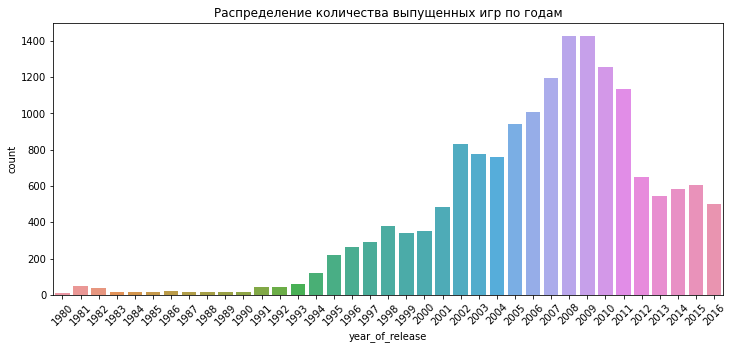

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(x='year_of_release', data=df)
plt.title('Распределение количества выпущенных игр по годам')  
plt.xticks(rotation=45)
plt.show()

**По графику видно наглядно, как в 90-ые годы происходит значительный рост в разработке и выпуске кол-ва компьютреных игр. Ранние годы выпуска игр с небольшим кол-вом данных уже не представляют интереса для анализа и прогноза успеха новых современных игр, данные устаревшие можно удалить. Определим порог выпуска кол-ва игр в год, построим диаграмму размаха.**

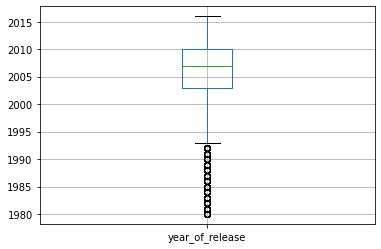

In [30]:
# Построение диаграммы размаха
df.boxplot(column=['year_of_release'])
plt.show()

In [31]:
# Расчёт границ межквартильного размаха
q1 = np.percentile(df['year_of_release'], 25)  # Первый квартиль (25%)
q3 = np.percentile(df['year_of_release'], 75)  # Третий квартиль (75%)
iqr = q3 - q1   # Межквартильный размах

# Границы усов
print('Левая граница межквартильного размаха:',q1 - 1.5 * iqr)

Левая граница межквартильного размаха: 1992.5


**Согласно диаграмме размаха , данные до 1993 года можно считать не актуальными.** 

**Сформируем новый датафрейм с актуальными данными.**

In [32]:
df_filter = df.query('year_of_release >= 1993')
print('Доля потери данных:',round((len(df)-len(df_filter))/len(df)*100,2),'%')

Доля потери данных: 1.85 %


**Построим динамику продаж игр с 1993 по 2016 годы.**

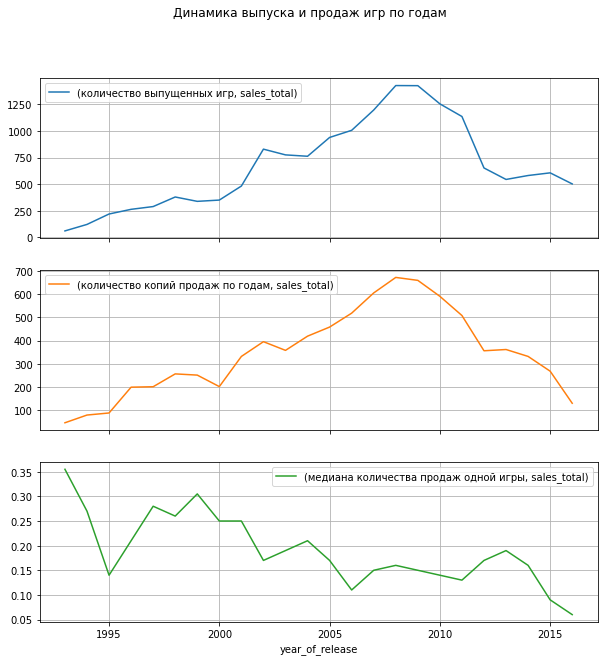

In [33]:
df_filter.pivot_table(index='year_of_release',
                      values='sales_total',
                      aggfunc=['count','sum','median'])\
.rename(columns={'count':'количество выпущенных игр',
                 'sum':'количество копий продаж по годам',
                 'median':'медиана количества продаж одной игры'})\
.plot(subplots=True,
      figsize = (10,10),
      grid=True,
      title = 'Динамика выпуска и продаж игр по годам')
plt.show()

**Краткое резюме: По графикам выдно, что с 2000 по 2009 годы игровая индустрия резко набирает обороты: начинается массовый выпуск новых релизов и значительный рост продаж. с 2010 года начинается спад в продажах и выпуске новых релизов. Но из-за ограничений в емкости рынка, доля продаж в пересчете на игру становится только ниже с каждым годом.**

**Падение рынка игр может быть связано:**
- с перенасыщением и усталостью аудитории.
- в технологической гонке непосильный рост стоимости разработки и большие ресурсы на адаптацию движков.
- в 2010-ые годы начинается рост продаж смартфонов, аудиотрия стала перетекать на игры в мобильных телефонах

### Динамика продаж по платформам. Топ- 15 платформ.

**Рассмотрим динамику развития продаж на одну платформу.**

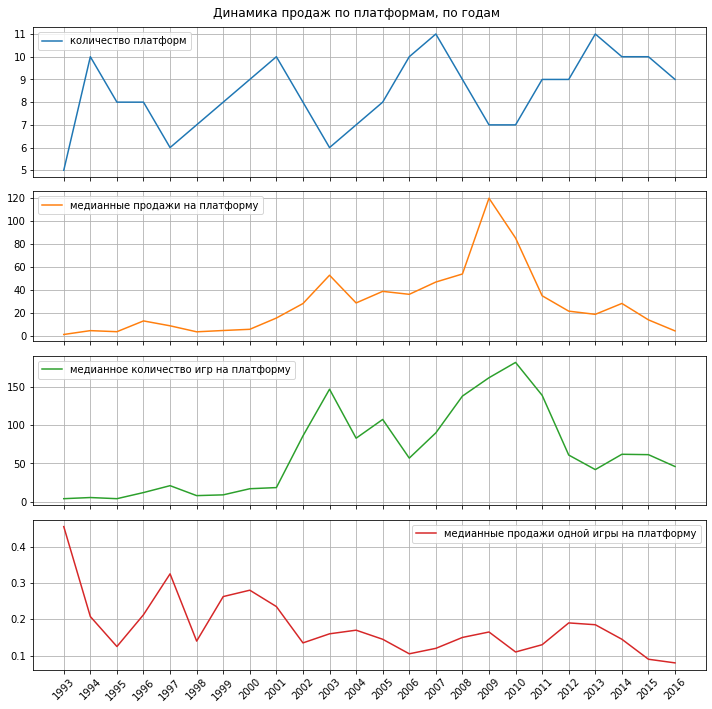

In [34]:
# формируем сводную таблицу с продажами по годам и платформам
sales_platform_year = df_filter.pivot_table(index=['year_of_release','platform'],
                      values='sales_total',
                      aggfunc=['count','sum','median'])
# переименование столбцов
sales_platform_year.columns = ['count_game','sales','median_sales_game']
sales_platform_year=sales_platform_year.reset_index()
# расчет статистики продаж на 1 платформу
sales_platform_year=(sales_platform_year.groupby('year_of_release')
                     .agg({'platform':'count',
                           'count_game':'median',
                           'sales':'median',
                           'median_sales_game':'median'}))
# переименование столбцов
sales_platform_year.columns = ['количество платформ',
                               'медианное количество игр на платформу',
                               'медианные продажи на платформу',
                               'медианные продажи одной игры на платформу']
sales_platform_year=sales_platform_year.reset_index()

# строим графики по каждому показателю
(sales_platform_year[['количество платформ',
                      'медианные продажи на платформу',
                     'медианное количество игр на платформу',
                     'медианные продажи одной игры на платформу']]
 .plot(subplots=True,
      figsize = (10,10),
      grid=True,
      title = 'Динамика продаж по платформам, по годам'))
 
# Принудительно выводим все года на ось X
plt.xticks(ticks=range(len(sales_platform_year['year_of_release'])), 
           labels=sales_platform_year['year_of_release'],
           rotation=45) 

plt.tight_layout()
plt.show()


**Краткое резюме.**

**Интересное наблюдение: примерно каждые 6-7 лет происходит рост и падение кол-ва платформ-это похоже на обновление. Максимальное кол-во в каждый цикл 10-11 платформ.**

**Медианные продажи и кол-во игр в пересчете на одну платформу похожи на развитие общих продаж. Основные продажи и выпуск новых игр приходятся на 2000-2010 года. После происходит падение.**

**В 2008-2009 году был пик общих продаж по рынку игр, при этом в этом году происходит цикл смены платформ и всего 7 платформ собрали самое большое кол-во продаж.** 

**Медианные продажи на 1 игру одной платформы также , как при общих продажах падают, чем больше игр, тем меньше продаж собирает одна игра.**



**Выделим топ - 15 платформ за весь период продаж, с 1993 года.**

In [35]:
# сводная общих продаж по платформам
top_platform = (df_filter
                .pivot_table(index='platform',
                             values='sales_total',
                             aggfunc='sum')
                .sort_values(by='sales_total', ascending=False).reset_index())

top_platform = top_platform.head(15)
top_platform 

,platform,sales_total
0,PS2,1233.56
1,X360,961.24
2,PS3,931.33
3,Wii,891.18
4,DS,802.76
5,PS,727.58
6,PS4,314.14
7,GBA,312.88
8,PSP,289.53
9,3DS,257.81


In [36]:
# динамика продаж по платформам из топ-15
sales_platform = (df_filter.groupby('platform')
                  .agg({'sales_total':['sum','median'],'name':'count'})
                  .reset_index())
sales_platform.columns=['платформа',
                        'общие продажи',
                        'медианные продажи на одну игру',
                        'количество игр']
sales_platform = (sales_platform[sales_platform['платформа']
                                 .isin(top_platform['platform'])]
                  .sort_values(by='общие продажи',ascending=False)
                  .reset_index(drop=True))
sales_platform 

,платформа,общие продажи,медианные продажи на одну игру,количество игр
0,PS2,1233.56,0.23,2127
1,X360,961.24,0.28,1232
2,PS3,931.33,0.28,1305
3,Wii,891.18,0.19,1286
4,DS,802.76,0.11,2120
5,PS,727.58,0.26,1190
6,PS4,314.14,0.20,392
7,GBA,312.88,0.16,811
8,PSP,289.53,0.09,1193
9,3DS,257.81,0.12,512


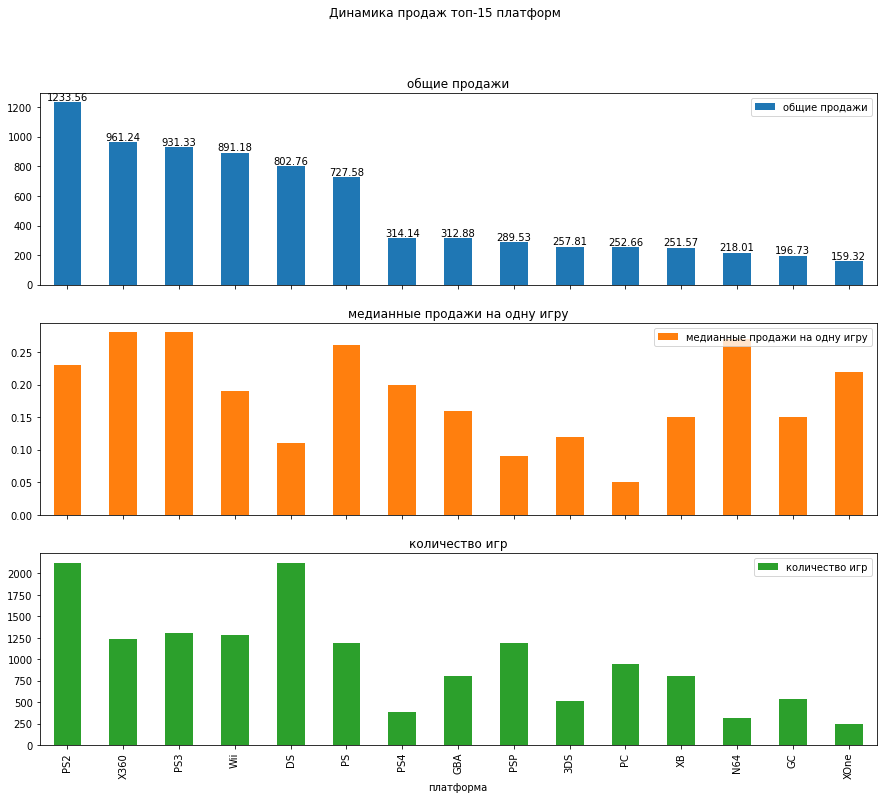

In [37]:
# строим график динамики продаж по платформам топ-15
ax= (sales_platform
     .plot(kind='bar',x = 'платформа', subplots=True,
      figsize = (15,12),
      title = 'Динамика продаж топ-15 платформ')
)

# Добавление аннотаций с суммой продаж
for i, (platform, sales) in enumerate(zip(sales_platform['платформа'], sales_platform['общие продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, sales_platform['общие продажи'].iloc[i]), 
                   ha='center', va='bottom')

plt.show()

**Самые успешные платформы по объёму продаж за всё время, по убыванию, - это PS2, X360, PS3, Wii, DS, PS с продажами  1234, 961, 931,891, 803 и 728 млн. копий. Самые высокие продажи у этих платформ достигаютсся в том числе за счет большого кол-ва выпущенных релизов. Самое большое количество игр у PS2-2127 релизов  и DS-2120 релизов. У остальных платформ  не более 1305 релизов.** 

**Самые успешные платформы по медианному кол-ву продаж на одну игру: X360, PS3 по 0,28 млн. копий; N64 0,27 млн. копий; PS 0,26 млн. копий; XOne 0,22 млн. копий; PS4 0,20 млн. копий.**	

In [38]:
# Выводим график 
fig = px.bar(df_filter[df_filter['platform'].isin(top_platform['platform'])] \
    .pivot_table(index=['platform', 'year_of_release'],
                 values='sales_total',
                 aggfunc='sum') \
    .reset_index(),
             x='year_of_release',
             y='sales_total',
             color='platform',
             color_discrete_sequence=px.colors.qualitative.Light24,
             text='platform'
            )
fig.update_layout(title ={'text': 'Продажи по платформам, по годам', 'font': {'size': 15}},
                  title_x = 0.55,
                  xaxis_title = 'Год',
                  yaxis_title = 'Продажи млн. копий',
                  yaxis={'categoryorder':'total ascending'},
                  template="plotly_white"
)
fig.show()

**На графике четко прослеживается цикличность смены платформ, жизненный цикл одной платформы примерно 6-9 лет, платформа набирает популярность и обороты продаж, теряет актуальность и на смену приходит другая платформа или модифицированная, такая как серия PS. Последние 2 цикла были примерно с 2005 по 2012 и с 2013 г. по текущий период в датафрейм.**

**Продажи у топ - платформ, которые были ранее определены, PS2, X360, PS3, Wii, DS, PS приходятся на период до 2012 года. После 2012 продажи по ним падают и стремятся к нулю. Данные по ним уже теряют свою атуальность для прогноза успешности новых игр.**

**По графику можно выделить 2 потенциально успешные платформы: PS4 и XOne. Также ранее эти платформы были отмечены в топе по самым высоким продажам на 1 игру.**



### Определение актуального периода для прогноза успешности новых игр в 2017 году. 

**Для точного определения актуального периода и платформ, на которые можно далее опираться для прогноза успешности новых игр определим точный жизненный цикл платформ.**

In [39]:
# определение длительности сущестования каждой платформы
platform_life = df_filter.pivot_table(index='platform',
                                      values='year_of_release',
                                      aggfunc=['min','max']).reset_index()
platform_life.columns = ['платформа','первый год','последний год']
# добавление колонки с расчетом количества лет платформы
platform_life['годы сущестования']=platform_life['последний год']-platform_life['первый год']
platform_life = (platform_life
                 .sort_values(by='первый год',ascending=False)
                 .reset_index(drop=True))
display(platform_life)
print('Медиана длительности существования одной платформы равна:',platform_life['годы сущестования']
      .median(), 'годам')

,платформа,первый год,последний год,годы сущестования
0,XOne,2013,2016,3
1,PS4,2013,2016,3
2,WiiU,2012,2016,4
3,3DS,2011,2016,5
4,PSV,2011,2016,5
5,Wii,2006,2016,10
6,PS3,2006,2016,10
7,X360,2005,2016,11
8,DS,2004,2013,9
9,PSP,2004,2015,11


Медиана длительности существования одной платформы равна: 6.0 годам


**Медиана жизненного цикла одной платформы равна 6 годам. В неоконченный жизненный цикл попадают платформы, которые появились с 2011 года: PSV, 3DS, WiiU, PS4 и XOne . Платформы PSV, 3DS, WiiU уже пережили пик своих продаж. Остаются актуальными платформы PS4 и XOne, вышедшие в 2013 году. По ним наблюдаются и самые высокие продажи среди прочих.**

**Будем считать акутальным перидом для дальнейшего анализа и прогнозирования  период с 2013 года.**

In [40]:
# новый датафрейм с акутальным перидос , с 2013 года.
df_actuel = df_filter.query('year_of_release >= 2013')
df_actuel.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16442
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     991 non-null    float64
 9   user_score       1192 non-null   float64
 10  rating           1256 non-null   object 
 11  sales_total      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 229.0+ KB


### Анализ продаж по платформам с 2013 года.

**Рассмотрим подробнее динамику продаж по платформам с 2013 года.**

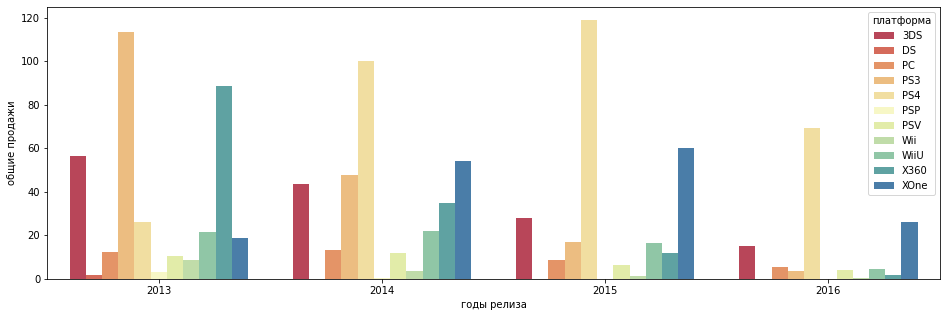

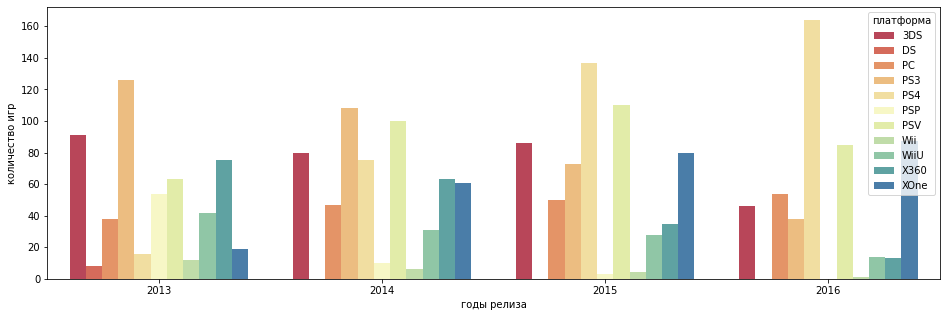

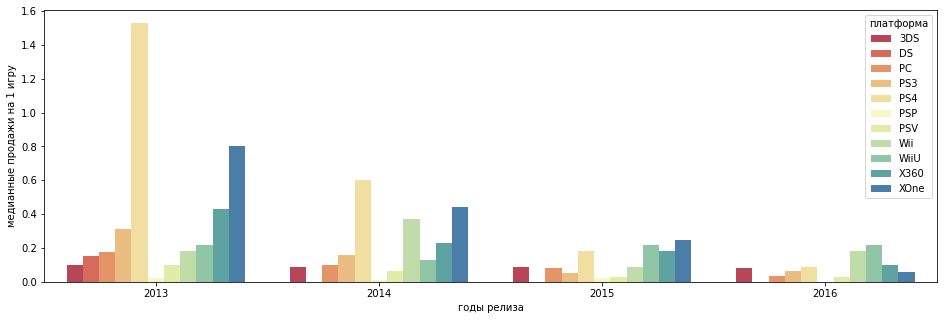

In [41]:
# сводная продаж по годам и по платформам 
platfrom_sales_actuel = (df_actuel
                         .groupby(by=['year_of_release','platform'])
                         .agg({'sales_total':['sum','median']
                               ,'name':'count'})
                         .reset_index())
platfrom_sales_actuel.columns = ['годы релиза',
                                 'платформа',
                                 'общие продажи',
                                 'медианные продажи на 1 игру',
                                 'количество игр']
# строим графики по каждому параметру
plt.figure(figsize=(16, 5))
sns.barplot(
    data=platfrom_sales_actuel,
    x='годы релиза',
    y='общие продажи',  
    hue='платформа',
    palette='Spectral')
plt.show()

plt.figure(figsize=(16, 5))
sns.barplot(
    data=platfrom_sales_actuel,
    x='годы релиза',
    y='количество игр',  
    hue='платформа',
    palette='Spectral')
plt.show()

plt.figure(figsize=(16, 5))
sns.barplot(
    data=platfrom_sales_actuel,
    x='годы релиза',
    y='медианные продажи на 1 игру',  
    hue='платформа',
    palette='Spectral')
plt.show()



**Учитывая, что за 2016 год данные не полные, будем ориентроваться на продажи 2013-2015 гг.**

**По графику также видно, что продажи растут только у платформ PS4 и XOne , по ним же растет кол-во выпущенных релизов. Остальные платформы падают в общих продажах, при том, что другие платфомы также наращивают кол-во игр.**

### Диаграмма размаха по глобальным продажам игр в разбивке по платформам.

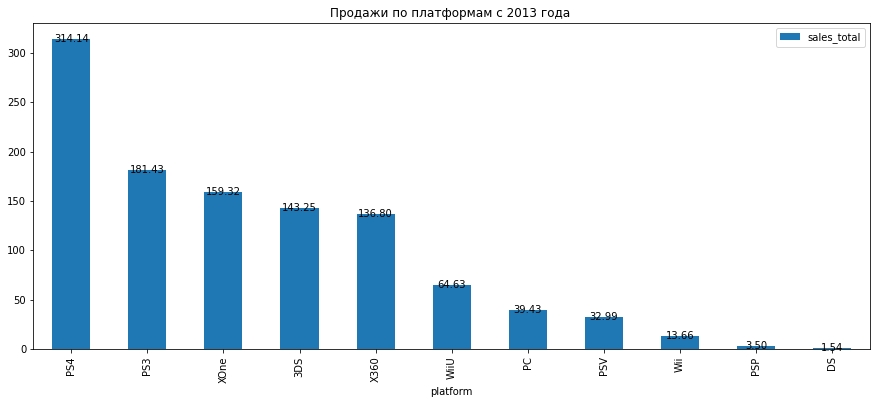

In [42]:
# строим график по общим продажам по платформам

sales_platform_actuel = df_actuel.groupby('platform')['sales_total'].sum().sort_values(ascending=False).reset_index()
ax = (sales_platform_actuel
     .plot(kind='bar',x = 'platform',
      figsize = (15,6),
      title = 'Продажи по платформам с 2013 года ')
)


# Добавление аннотаций с суммой продаж
for index, value in enumerate(sales_platform_actuel['sales_total']):
    plt.text(index, value, f'{value:.2f}', ha='center', va='center',fontsize=10)

plt.show()

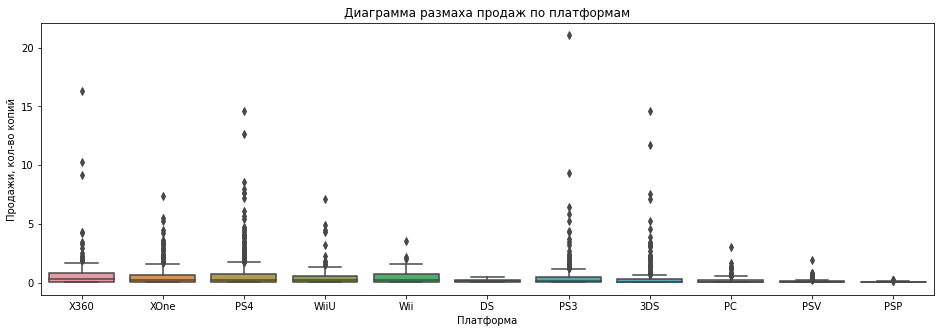

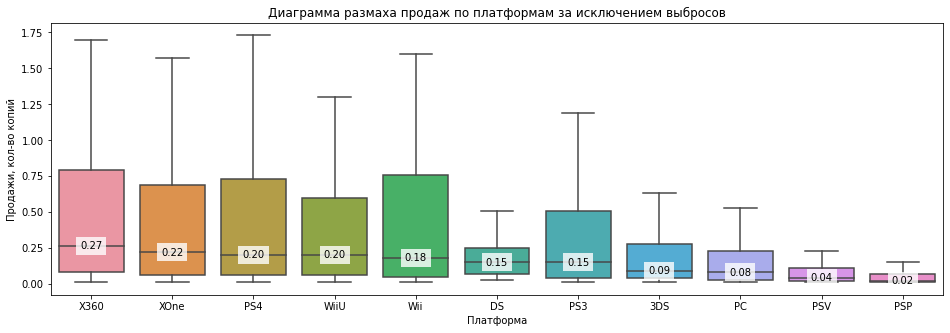

In [43]:
# Строим диаграмму размаха по продажам платформ за акутальный период 
plt.figure(figsize=(16, 5))
sns.boxplot(x='platform', y='sales_total', data=df_actuel,
            order = df_actuel.groupby('platform')['sales_total']
            .median().sort_values(ascending=False).index)
plt.title('Диаграмма размаха продаж по платформам')
plt.xlabel('Платформа')
plt.ylabel('Продажи, кол-во копий')
plt.show()

# диаграмму размаха за исключением выбросов 
plt.figure(figsize=(16, 5))
ax = sns.boxplot(x='platform', y='sales_total', data=df_actuel, showfliers=False,
            order = df_actuel.groupby('platform')['sales_total']
            .median().sort_values(ascending=False).index)

# Добавляем подписи медиан
for i, platform in enumerate(df_actuel.groupby('platform')['sales_total']
                                   .median()
                                   .sort_values(ascending=False)
                                   .index):
    median_val = df_actuel[df_actuel['platform'] == platform]['sales_total'].median()
    ax.text(i, median_val, f'{median_val:.2f}', 
            ha='center', va='center', 
            fontsize=10, color='black',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
plt.title('Диаграмма размаха продаж по платформам за исключением выбросов')
plt.xlabel('Платформа')
plt.ylabel('Продажи, кол-во копий')
plt.show()

**По общим продажам с 2013 года ещё держатся старые платформы, такие как X360, которая существует с 2005 года , PS3 -существующая с 2006 года,  но и новые платформы выходят в лидеры, PS4 и XOne.**

**Лидеры общих продаж платформы PS4 -314 млн. копий , PS3-181 млн. копий и XOne -159 млн. копий.
В лидерах по медиане продаж на одну игру платформа X360- 0,27 млн копий. На втором и третьем местах XOne - 0,22 млн. копий и PS4 - 0,20 млн. копий.** 

### Оценка влияния отзывов пользователей и критиков на продажи внутри платформ.

**Для оценки влияния отзывов пользователей и критиков на продажи по патформам вычислим корреляцию между отзывами и продажами и построим диаграмму рассеяния.**

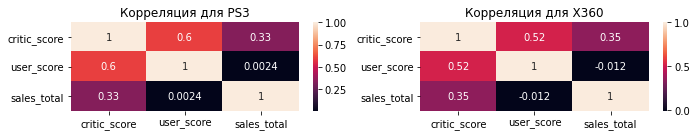

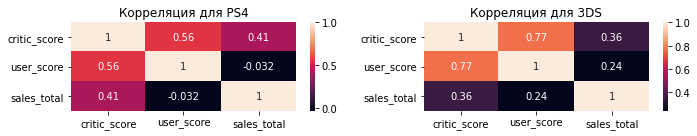

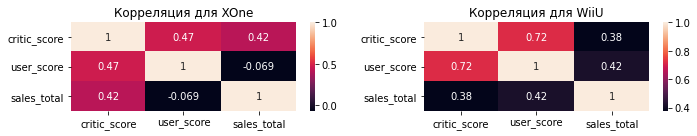

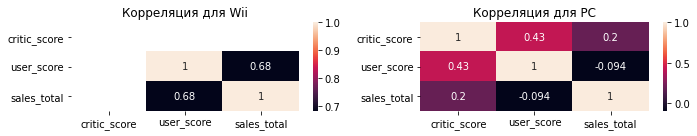

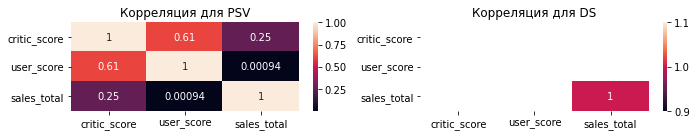

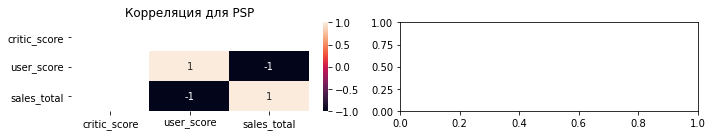

In [44]:
platforms = df_actuel['platform'].unique()
df_score = df_actuel.drop(columns =['year_of_release','na_sales','eu_sales','jp_sales','other_sales'])

# создаем фигуру с двумя subplots в одной строке
fig, axes = plt.subplots(1,2, figsize=(10,2))  # 1 строка, 2 столбца

for i, platform in enumerate(platforms):
        
    platform_data = df_score[df_actuel['platform'] == platform]
    corr_matrix = platform_data.corr()
    
    # выбираем соответствующий subplot
    ax = axes[i % 2]  # i % 2 даст 0 или 1 для позиции в строке
    
    sns.heatmap(corr_matrix, annot=True, ax=ax)
    ax.set_title(f'Корреляция для {platform}')
    
    # если обработали 2 графика, показываем и создаем новую строку
    if (i + 1) % 2 == 0 or i == len(platforms) - 1:
        plt.tight_layout()
        plt.show()
        if i < len(platforms) - 1:  # если остались платформы
            fig, axes = plt.subplots(1, 2, figsize=(10, 2))

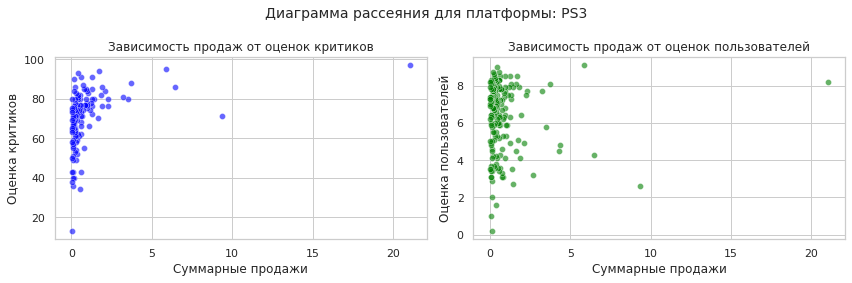

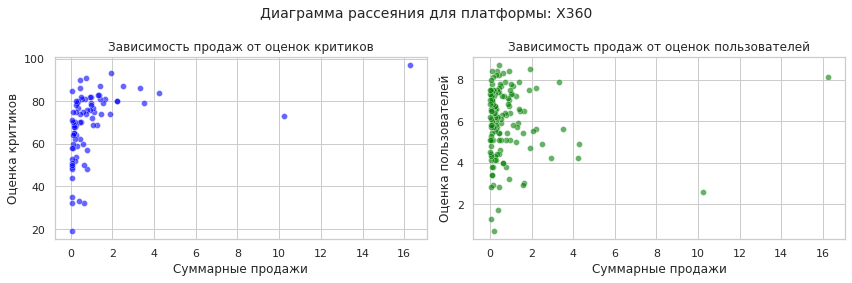

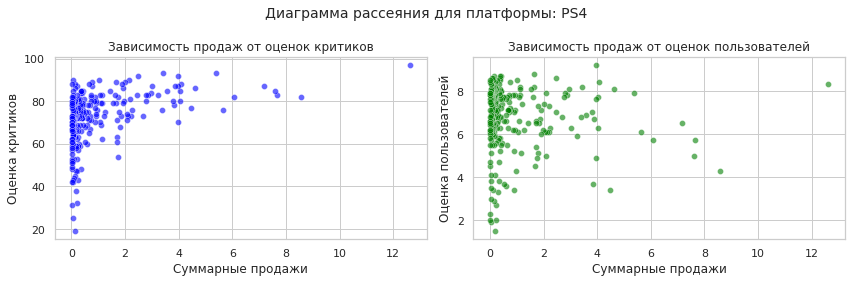

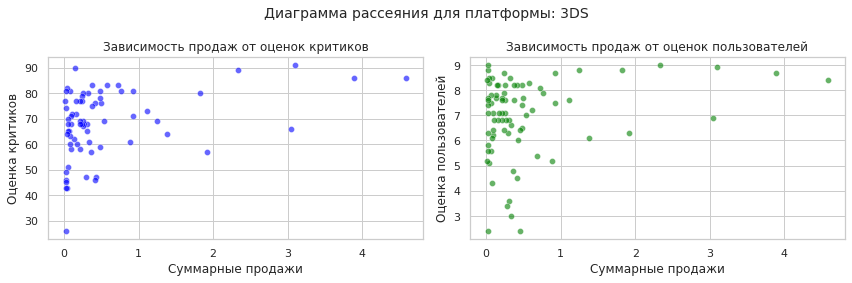

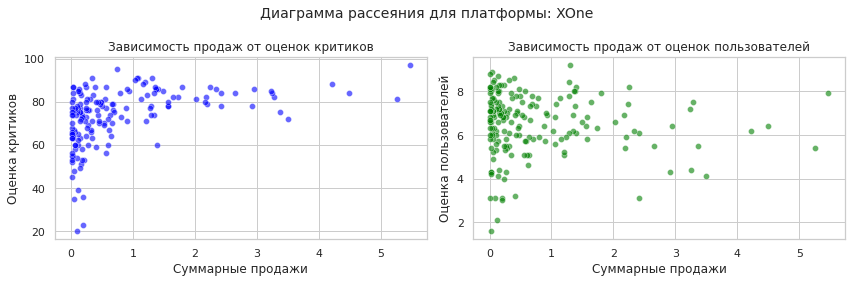

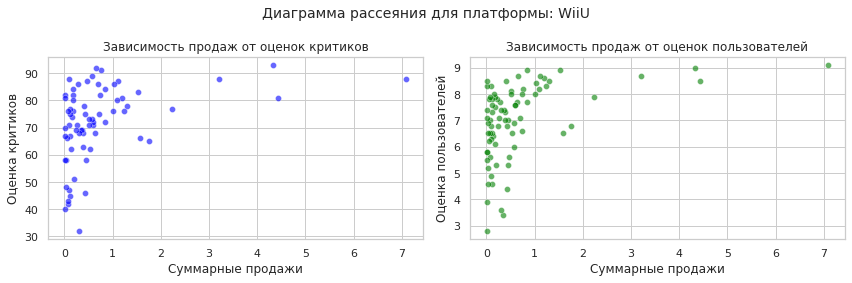

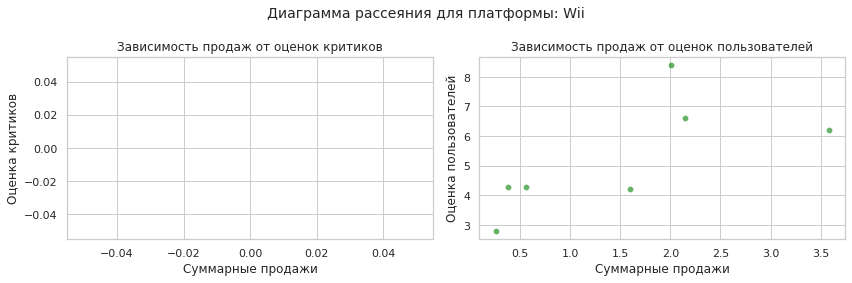

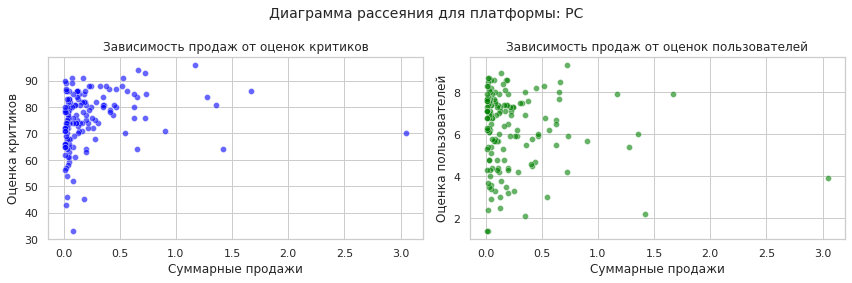

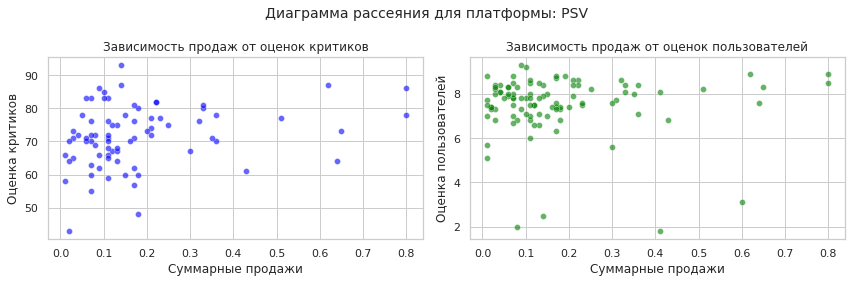

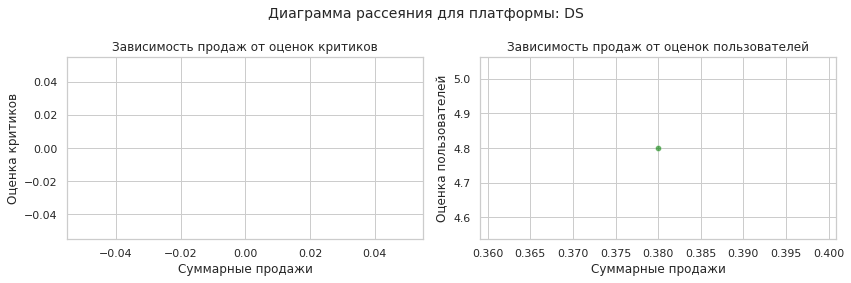

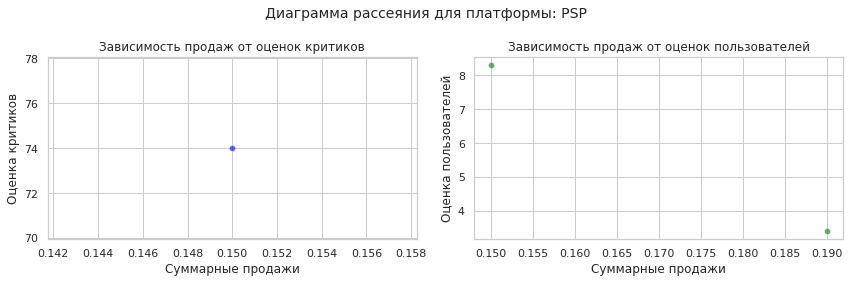

In [45]:
# уникальные платформы
platforms = df_actuel['platform'].unique()

# Настройка стиля
sns.set(style="whitegrid")

# Для каждой платформы создаем строку с 2 графиками
for platform in platforms:
    # Фильтруем данные по платформе
    platform_data = df_actuel[df_actuel['platform'] == platform]
    
    # Создаем фигуру с 2 subplots в одной строке
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Диаграмма рассеяния для платформы: {platform}', fontsize=14)
    
    # График 1: Продажи vs оценки критиков
    sns.scatterplot(
        data=platform_data,
        x='sales_total',
        y='critic_score',
        ax=ax1,
        color='blue',
        alpha=0.6
    )
    ax1.set_title('Зависимость продаж от оценок критиков')
    ax1.set_xlabel('Суммарные продажи')
    ax1.set_ylabel('Оценка критиков')
    
    # График 2: Продажи vs оценки пользователей
    sns.scatterplot(
        data=platform_data,
        x='sales_total',
        y='user_score',
        ax=ax2,
        color='green',
        alpha=0.6
    )
    ax2.set_title('Зависимость продаж от оценок пользователей')
    ax2.set_xlabel('Суммарные продажи')
    ax2.set_ylabel('Оценка пользователей')
    
    # Оптимизация расположения
    plt.tight_layout()
    plt.show()

**Наблюдается влияние оценок критиков на продажи, корреляция зависимости умеренная. Если взять корреляцию по потенциально прибыльным платформам PS4 и XOne , корреляция равна 0,41 и 0,42. Это самая высокая корреляция зависимости продаж от оценок критиков. У платформ X360 и PS3 корреляция равна 0,35 и 0,33. У платформы Wii корреляция 0,68, но данных очень мало, поэтому в расчет не берем.** 


**Корреляция зависимости продаж от оценок пользователей стремится к нулю, зависимость не наблюдается ни по одной платформе. Выделилась только одна платформа, WiiU которой присутствует корреляция равная 0,42. На Wii U вышло с 2013 года по 2016 всего 115 игр, из которых лишь 30–40 были значимыми эксклюзивами (например, Mario Kart 8, Super Smash Bros.). Это создаёт более однородную выборку, где качество (оценки) сильнее влияет на продажи.**

### Распределение игр по жанрам. 

сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [46]:
# сводная таблица с продажами по жанрам 
sales_genre = (df_actuel.groupby('genre')
               .agg({'sales_total':['sum','median'],
                     'name':'count'}).reset_index())
sales_genre.columns=['жанр','общие продажи','медианные продажи на одну игру','количество игр']
sales_genre = sales_genre.sort_values(by='общие продажи',ascending=False)
sales_genre 

,жанр,общие продажи,медианные продажи на одну игру,количество игр
0,Action,321.87,0.110,766
8,Shooter,232.98,0.450,187
10,Sports,150.65,0.240,214
7,Role-Playing,145.89,0.125,292
3,Misc,62.82,0.100,155
4,Platform,42.63,0.225,74
6,Racing,39.89,0.120,85
2,Fighting,35.31,0.125,80
1,Adventure,23.64,0.030,245
9,Simulation,21.76,0.100,62


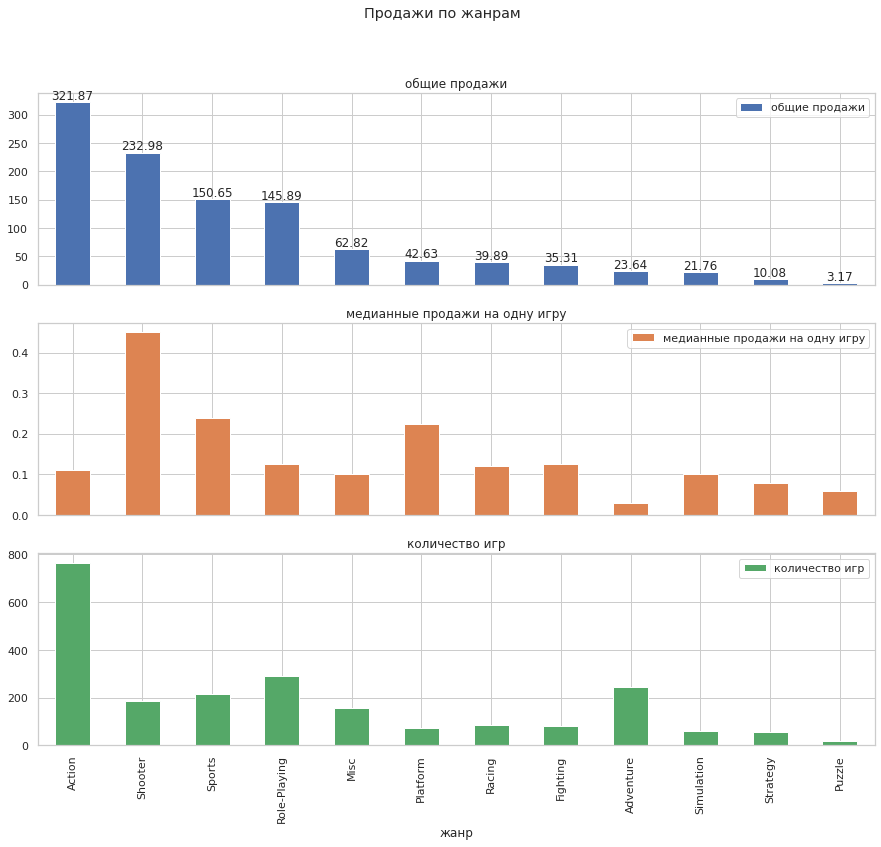

In [47]:
# построение графика по всем признакам
ax = sales_genre.plot(kind='bar',x = 'жанр', subplots=True,
      figsize = (15,12),
      title = 'Продажи по жанрам')

   
# Добавление аннотаций с суммой продаж (тоже на первый график)
for i, (platform, sales) in enumerate(zip(sales_genre['жанр'], sales_genre['общие продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, sales_genre['общие продажи'].iloc[i]), 
                   ha='center', va='bottom')

plt.show()

**Топ -4 жанра, которые выделяются по продажам за период 2013-2016 г.: Action, Shooter, Sports, Role-Playing, с продажами 322, 233, 151, 146 млн. копий. Другие жанры имеют продажи от 10 до 63 млн. копий.**

**При этом жанр Action с самыми высокими продажами имеет самое большое кол-во игр 766, но медианные продажи низкие, всего 0,11 млн копий на одну игру. У остальных жанров кол-во игр не так значительно отличается и достигает не более 292 игр. При этом жанр Shooter имеет всего 187 игр , но самые высокие медианные продажи, заняв 2 место по общим продажам.**

**Самые низкие показатели по всем признакам имеют жанры Strategy и Puzzle, всего 10 и 3 млн копий. У Puzzle всего лишь 17 видов игр.**

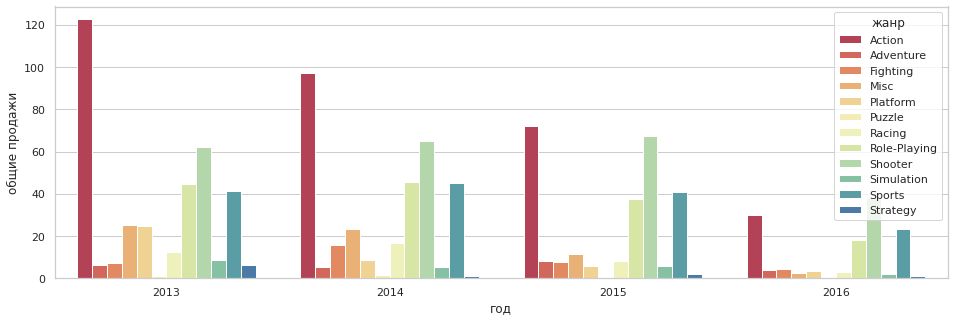

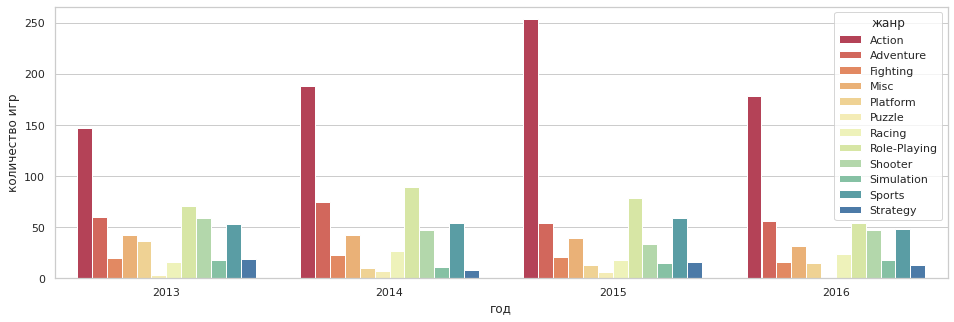

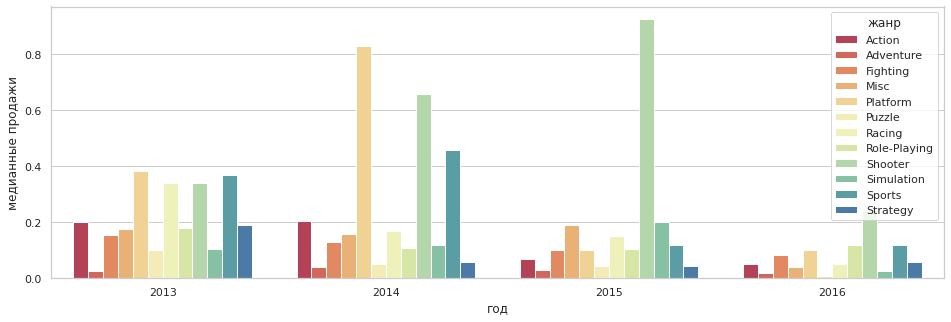

In [48]:
# сводная таблица с продажами по жанрам и по годам
genre_year_dinamic = (df_actuel
                      .groupby(by=['year_of_release','genre'])
                      .agg({'sales_total':['sum','median'],
                            'name':'count'}).reset_index())
genre_year_dinamic.columns = ['год','жанр','общие продажи','медианные продажи','количество игр']

# графики по признакам
plt.figure(figsize=(16, 5))
sns.barplot(
    data=genre_year_dinamic,
    x='год',
    y='общие продажи',  
    hue='жанр',
    palette='Spectral')

plt.show()

plt.figure(figsize=(16, 5))
sns.barplot(
    data=genre_year_dinamic,
    x='год',
    y='количество игр',  
    hue='жанр',
    palette='Spectral')
plt.show()

plt.figure(figsize=(16, 5))
sns.barplot(
    data=genre_year_dinamic,
    x='год',
    y='медианные продажи',  
    hue='жанр',
    palette='Spectral')
plt.show()


In [49]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Shooter"')['platform'].value_counts()

PS4     41
XOne    38
X360    34
PC      32
PS3     31
WiiU     8
PSV      2
3DS      1
Name: platform, dtype: int64

In [50]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Sports"')['platform'].value_counts()

PS3     47
PS4     46
XOne    38
X360    31
PSV     17
PC      13
3DS      8
WiiU     5
PSP      5
Wii      3
DS       1
Name: platform, dtype: int64

In [51]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Role-Playing"')['platform'].value_counts()

PSV     78
3DS     62
PS4     51
PS3     49
PC      18
XOne    14
X360     8
PSP      7
WiiU     5
Name: platform, dtype: int64

In [52]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Action"')['platform'].value_counts()

PS4     144
PSV     125
3DS     116
PS3     114
XOne     85
X360     62
PC       50
WiiU     48
PSP      12
Wii       8
DS        2
Name: platform, dtype: int64

In [53]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Puzzle"')['platform'].value_counts()

3DS     9
WiiU    4
PSV     2
PS3     1
PS4     1
Name: platform, dtype: int64

In [54]:
# кол-во игр жанра по платформам
df_actuel.query('genre=="Strategy"')['platform'].value_counts()

PC      20
3DS     11
PSV      7
PS4      6
PS3      4
XOne     3
WiiU     2
Wii      1
PSP      1
X360     1
Name: platform, dtype: int64

**В динамике по годам видно, что все жанры каждый год выдерживают примерно 1 уровень продаж, без значительных отклонений на рост или падение. И только общие продажи по жанру Action падают с каждым годом, но растет кол-во игр. В то время, как у другх платформ также без значительных изменений по выпущенному кол-ву игр.**


**Жанр Shooter можно назвать одним из самых перспективных, так как при неизменном кол-ве игр растет медианное кол-во продаж на 1 игру. Также к перспективным жанрам можно отнести Sports, основные платформы этих жанров PS4 и XOne.**

**А жанры с самыми назкими продажами Strategy и Puzzle представлены в основном на старых платформа.**



## Портрет пользователя каждого региона

### Самые популярные платформы (топ-5)  каждого региона (NA, EU, JP):

In [55]:
# подготовка данных, замена 0 на пустые значения 
df_region = df_actuel[['eu_sales', 'jp_sales', 'na_sales', 'platform', 'sales_total']].replace(0, np.nan)

# Создание сводной таблицы продаж по регионам
region_sales = df_region.pivot_table(
    index='platform',
    values=['na_sales', 'eu_sales', 'jp_sales', 'sales_total'],
    aggfunc=['sum', 'median', 'count']
)
region_sales.columns =( ['европа_продажи','япония_продажи','америка_продажи','общие продажи',
                         'европа_медиана_продаж','япония_медиана_продаж','америка_медиана_продаж',
                         'общая_медиана_продаж','европа_количество_игр','япония_количество_игр',
                         'америка_количество_игр','общее_количество_игр'])
region_sales = region_sales.drop(columns = ['общая_медиана_продаж','общее_количество_игр'])
region_sales['европа_продажи_доля'] = round(region_sales['европа_продажи'] /
                                            region_sales['европа_продажи'].sum(),2)
region_sales['япония_продажи_доля'] = round(region_sales['япония_продажи'] /
                                            region_sales['япония_продажи'].sum(),2)
region_sales['америка_продажи_доля'] = round(region_sales['америка_продажи'] /
                                             region_sales['америка_продажи'].sum(),2)
region_sales = region_sales.reset_index().sort_values(by='общие продажи', ascending=False)
region_sales

,platform,европа_продажи,япония_продажи,америка_продажи,общие продажи,европа_медиана_продаж,япония_медиана_продаж,америка_медиана_продаж,европа_количество_игр,япония_количество_игр,америка_количество_игр,европа_продажи_доля,япония_продажи_доля,америка_продажи_доля
4,PS4,141.09,15.96,108.74,314.14,0.160,0.05,0.110,290,223,294,0.36,0.11,0.25
3,PS3,67.81,23.35,63.50,181.43,0.115,0.05,0.110,212,236,211,0.17,0.17,0.15
10,XOne,51.59,0.34,93.12,159.32,0.090,0.01,0.150,218,22,227,0.13,0.00,0.21
0,3DS,30.96,67.81,38.20,143.25,0.080,0.08,0.090,122,235,119,0.08,0.48,0.09
9,X360,42.52,0.51,81.66,136.80,0.110,0.01,0.170,169,31,170,0.11,0.00,0.19
8,WiiU,19.85,10.88,29.21,64.63,0.100,0.09,0.170,96,57,92,0.05,0.08,0.07
2,PC,25.36,0.00,11.11,39.43,0.060,NaN,0.085,187,0,84,0.06,0.00,0.03
6,PSV,6.10,18.59,5.04,32.99,0.030,0.03,0.035,96,316,94,0.02,0.13,0.01
7,Wii,5.93,0.05,6.56,13.66,0.105,0.05,0.150,22,1,14,0.02,0.00,0.01
5,PSP,0.17,3.29,0.00,3.50,0.085,0.02,NaN,2,66,0,0.00,0.02,0.00


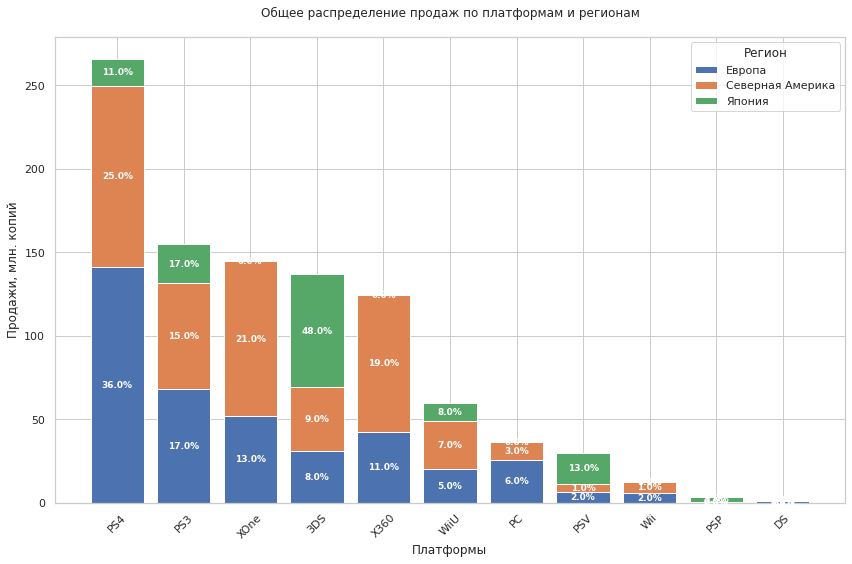

In [56]:
# подготовка данных
platforms = region_sales['platform']
regions = ['европа_продажи', 'америка_продажи', 'япония_продажи']  

region_names = ['Европа', 'Северная Америка', 'Япония']  # Красивые названия

# Создаем фигуру
plt.figure(figsize=(12, 8))

# Строим график
bottom = None
for region, name in zip(regions, region_names):
    bars = plt.bar(
        platforms,
        region_sales[region],
        bottom=bottom,
        label=name
    )
    bottom = region_sales[region] if bottom is None else bottom + region_sales[region]
    
    # добавляем подписи с долями внутри сегментов
    if bottom is not None:
        for j, (total, part) in enumerate(zip(bottom, region_sales[f'{region}_доля'])):
            y_pos = total - region_sales[region].iloc[j]/2  # Центр сегмента
            plt.text(
                j, y_pos,
                f'{part:.1%}',
                ha='center', va='center',
                color='white',
                fontweight='bold',
                fontsize=9
            )


# настройка графика
plt.title('Общее распределение продаж по платформам и регионам', pad=20)
plt.xlabel('Платформы')
plt.ylabel('Продажи, млн. копий')
plt.xticks(rotation=45)
plt.legend(title='Регион')
plt.tight_layout()
plt.show()

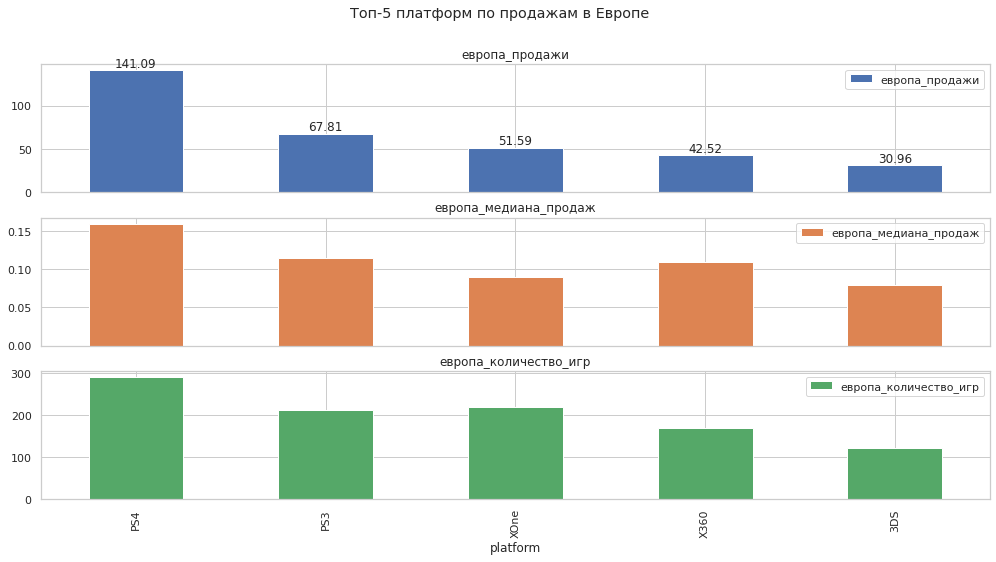

In [57]:
# Выбор нужных столбцов и сортировка
eu_sales = ['platform', 'европа_продажи', 'европа_медиана_продаж', 'европа_количество_игр']
eu_sorted_sales = region_sales[eu_sales].sort_values(by='европа_продажи', ascending=False).head()

# Построение графика
ax = eu_sorted_sales.plot(kind='bar', x='platform',
                          subplots=True, figsize=(17, 8),
                          title='Топ-5 платформ по продажам в Европе')

    
# Добавление аннотаций с суммой продаж (тоже на первый график)
for i, (platform, sales) in enumerate(zip(eu_sorted_sales['platform'], eu_sorted_sales['европа_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, eu_sorted_sales['европа_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

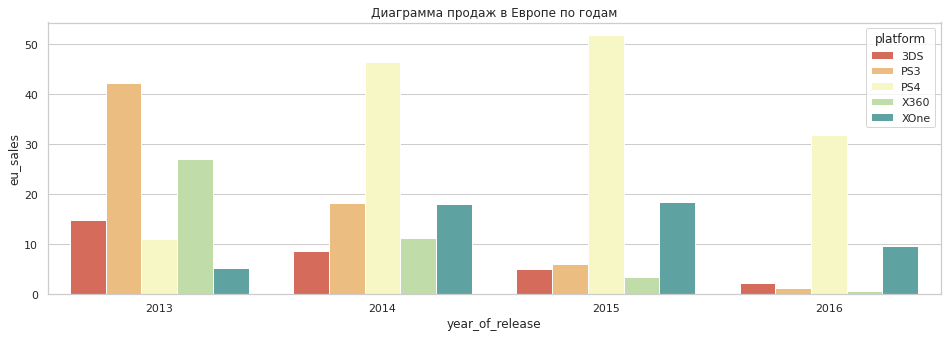

In [58]:
# строим сводную динамики продаж по европе
eu_year_dinamic = df_actuel.groupby(by=['year_of_release','platform']).agg({'eu_sales':'sum'}).reset_index()
eu_year_dinamic = eu_year_dinamic[eu_year_dinamic['platform'].isin(eu_sorted_sales['platform'])]

# график продаж по годам в европе
plt.figure(figsize=(16, 5))
sns.barplot(
    data=eu_year_dinamic,
    x='year_of_release',
    y='eu_sales',  
    hue= 'platform',
    palette='Spectral')
plt.title('Диаграмма продаж в Европе по годам')
plt.show()

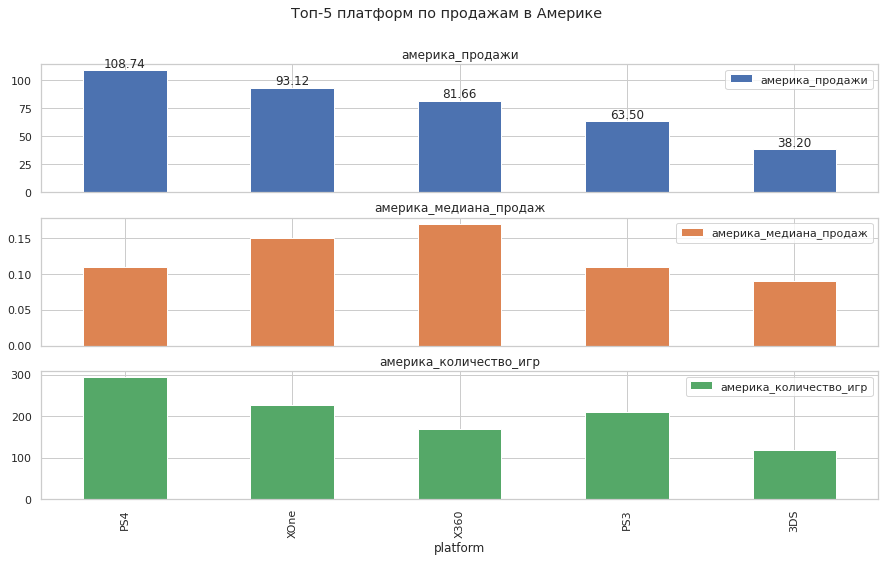

In [59]:
# Выбор нужных столбцов и сортировка
na_sales = ['platform', 'америка_продажи', 'америка_медиана_продаж', 'америка_количество_игр']
na_sorted_sales = region_sales[na_sales].sort_values(by='америка_продажи', ascending=False).head()

# Построение графика
ax = na_sorted_sales.plot(kind='bar', x='platform',
                          subplots=True, figsize=(15, 8),
                          title='Топ-5 платформ по продажам в Америке')
    
# Добавление аннотаций с суммой продаж
for i, (platform, sales) in enumerate(zip(na_sorted_sales['platform'], na_sorted_sales['америка_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, na_sorted_sales['америка_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

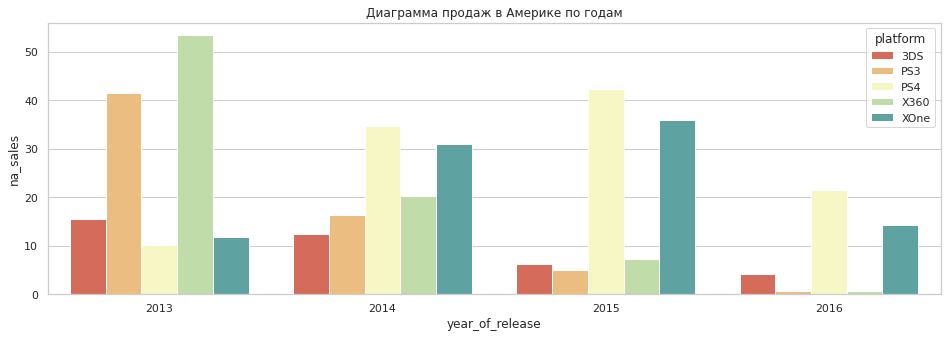

In [60]:
na_year_dinamic = df_actuel.groupby(by=['year_of_release','platform']).agg({'na_sales':'sum'}).reset_index()
na_year_dinamic = na_year_dinamic[na_year_dinamic['platform'].isin(na_sorted_sales['platform'])]

plt.figure(figsize=(16, 5))
sns.barplot(
    data=na_year_dinamic,
    x='year_of_release',
    y='na_sales',  
    hue='platform',
    palette='Spectral')
plt.title('Диаграмма продаж в Америке по годам')
plt.show()

In [61]:
region_sales.head(2)

,platform,европа_продажи,япония_продажи,америка_продажи,общие продажи,европа_медиана_продаж,япония_медиана_продаж,америка_медиана_продаж,европа_количество_игр,япония_количество_игр,америка_количество_игр,европа_продажи_доля,япония_продажи_доля,америка_продажи_доля
4,PS4,141.09,15.96,108.74,314.14,0.160,0.05,0.11,290,223,294,0.36,0.11,0.25
3,PS3,67.81,23.35,63.50,181.43,0.115,0.05,0.11,212,236,211,0.17,0.17,0.15


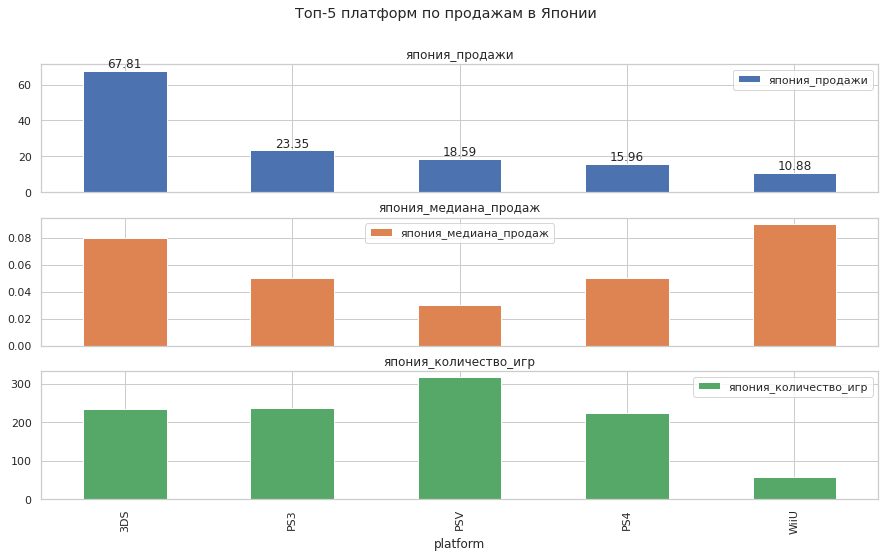

In [62]:
# выбор нужных столбцов и сортировка
jp_sales = ['platform', 'япония_продажи', 'япония_медиана_продаж', 'япония_количество_игр']
jp_sorted_sales = region_sales[jp_sales].sort_values(by='япония_продажи', ascending=False).head()

# построение графика
ax = jp_sorted_sales.plot(kind='bar', x='platform',
                          subplots=True, figsize=(15, 8), 
                          title='Топ-5 платформ по продажам в Японии')

# добавление аннотаций с суммой продаж
for i, (platform, sales) in enumerate(zip(jp_sorted_sales['platform'], jp_sorted_sales['япония_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, jp_sorted_sales['япония_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

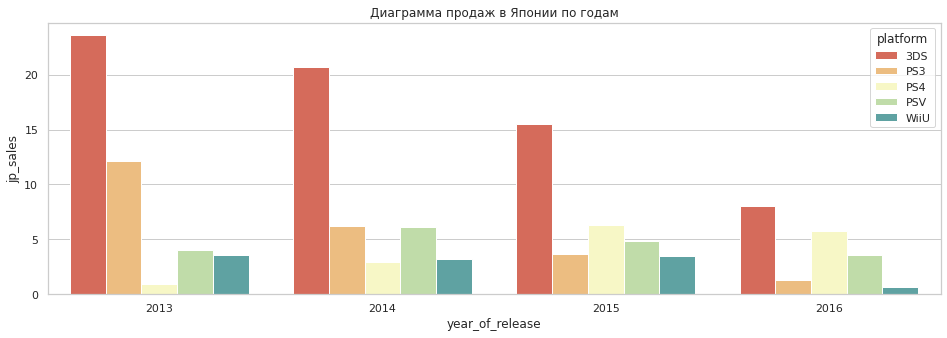

In [63]:
jp_year_dinamic = df_actuel.groupby(by=['year_of_release','platform']).agg({'jp_sales':'sum'}).reset_index()
jp_year_dinamic = jp_year_dinamic[jp_year_dinamic['platform'].isin(jp_sorted_sales['platform'])]

plt.figure(figsize=(16, 5))
sns.barplot(
    data=jp_year_dinamic,
    x='year_of_release',
    y='jp_sales',  
    hue='platform',
    palette='Spectral')
plt.title('Диаграмма продаж в Японии по годам')
plt.show()

**Самые популярные платформы в Европе - это PS4, PS3, XOne,X360, 3DS с долями продаж от общих, по порядку, 36%,17%,13%,11%,8%. И растут продажи по годам по PS4 и XOne, по остальным платформам падают.**

**Самые популярные платформы в Америке - PS4, XOne, X360, PS3, 3DS с долями продаж от общих, по порядку, 25%, 21%, 19%, 15%, 9%. Растут продажи также по годам по PS4 и XOne, по остальным платформам падают.**

**Самые популярные платформы в Японии - 3DS, PS3, PSV, PS4, WiiU с долями продаж от общих, по порядку, 48%, 17%, 13%, 11%, 8%. Растут продажи только по PS4 , по остальным платформам падают.** 

**Возможные причины разностей долей платформ по регионам:**

**Культура игр:**

- США: Любовь к шутерам (Call of Duty) и открытым мирам (GTA).

- Япония: Упор на RPG и визуальные новеллы.

- Европа: Популярность симуляторов (FIFA, The Sims).

**Экономика:**

- В Японии компактные консоли (3DS) удобны для маленьких жилых пространств.

- В Европе высокая стоимость лицензий стимулировала PC-гейминг.

**Маркетинг:**

- Sony активно продвигала PS4 в Европе через футбольные турниры.

- Nintendo делала ставку на локальные франшизы в Японии (Pokémon).



### Самые популярные жанры  (топ-5)  каждого региона (NA, EU, JP)

In [64]:
# подготовка данных
df_genre = df_actuel[['eu_sales', 'jp_sales', 'na_sales', 'genre', 'sales_total']].replace(0, np.nan)

# создание сводной таблицы по продажам по жанрам
region_genre = df_genre.pivot_table(
    index='genre',
    values=['na_sales', 'eu_sales', 'jp_sales', 'sales_total'],
    aggfunc=['sum', 'median', 'count']
)
region_genre.columns =( ['европа_продажи','япония_продажи','америка_продажи','общие продажи',
                         'европа_медиана_продаж','япония_медиана_продаж','америка_медиана_продаж',
                         'общие_медианные_продажи','европа_количество_игр','япония_количество_игр',
                         'америка_количество_игр','общее_количество_игр'])
region_genre['европа_продажи_доля'] = round(region_genre['европа_продажи'] /
                                            region_genre['европа_продажи'].sum(),2)
region_genre['япония_продажи_доля'] = round(region_genre['япония_продажи'] /
                                            region_genre['япония_продажи'].sum(),2)
region_genre['америка_продажи_доля'] = round(region_genre['америка_продажи'] /
                                             region_genre['америка_продажи'].sum(),2)
region_genre = region_genre.reset_index().sort_values(by='общие продажи', ascending=False)
region_genre

,genre,европа_продажи,япония_продажи,америка_продажи,общие продажи,европа_медиана_продаж,япония_медиана_продаж,америка_медиана_продаж,общие_медианные_продажи,европа_количество_игр,япония_количество_игр,америка_количество_игр,общее_количество_игр,европа_продажи_доля,япония_продажи_доля,америка_продажи_доля
0,Action,118.13,40.49,126.05,321.87,0.080,0.040,0.100,0.110,494,400,442,766,0.30,0.29,0.29
8,Shooter,87.86,6.61,109.74,232.98,0.230,0.040,0.220,0.450,171,69,171,187,0.22,0.05,0.25
10,Sports,60.52,5.41,65.27,150.65,0.090,0.070,0.270,0.240,169,60,143,214,0.15,0.04,0.15
7,Role-Playing,36.97,51.04,46.40,145.89,0.070,0.070,0.090,0.125,155,236,158,292,0.09,0.36,0.11
3,Misc,20.04,9.20,27.49,62.82,0.085,0.060,0.130,0.100,80,90,84,155,0.05,0.07,0.06
4,Platform,15.58,4.79,18.14,42.63,0.120,0.055,0.110,0.225,62,28,67,74,0.04,0.03,0.04
6,Racing,20.19,2.30,12.96,39.89,0.090,0.030,0.070,0.120,78,26,55,85,0.05,0.02,0.03
2,Fighting,8.55,7.65,15.55,35.31,0.070,0.050,0.095,0.125,49,59,52,80,0.02,0.05,0.04
1,Adventure,8.25,5.82,7.14,23.64,0.050,0.020,0.040,0.030,79,165,80,245,0.02,0.04,0.02
9,Simulation,10.92,4.52,4.86,21.76,0.080,0.040,0.075,0.100,44,21,28,62,0.03,0.03,0.01


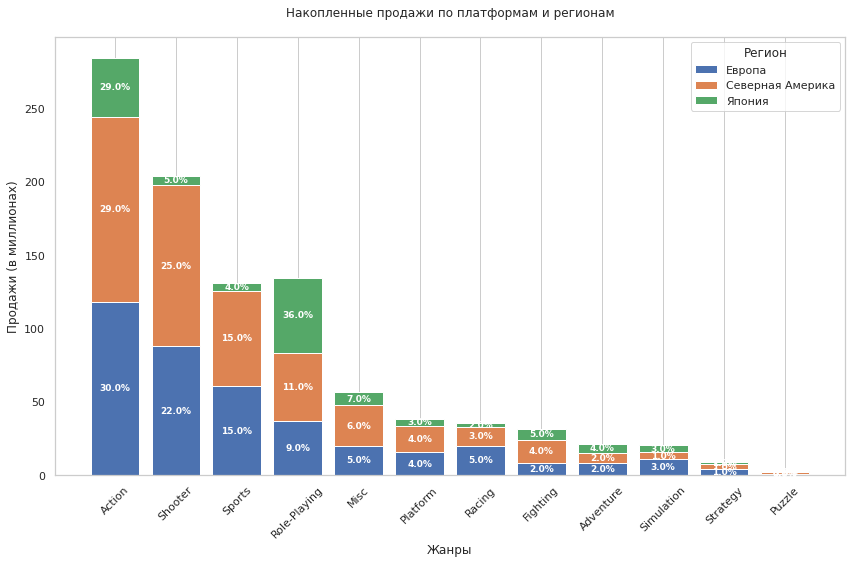

In [65]:
# подготовка данных
genre = region_genre['genre']


# создаем фигуру
plt.figure(figsize=(12, 8))

# Строим график
bottom = None
for region, name in zip(regions, region_names):
    bars = plt.bar(
        genre,
        region_genre[region],
        bottom=bottom,
        label=name
    )
    bottom = region_genre[region] if bottom is None else bottom + region_genre[region]
    
    # добавляем подписи с долями внутри сегментов
    if bottom is not None:
        for j, (total, part) in enumerate(zip(bottom, region_genre[f'{region}_доля'])):
            y_pos = total - region_genre[region].iloc[j]/2  # Центр сегмента
            plt.text(
                j, y_pos,
                f'{part:.1%}',
                ha='center', va='center',
                color='white',
                fontweight='bold',
                fontsize=9
            )


# Настройка графика
plt.title('Накопленные продажи по платформам и регионам', pad=20)
plt.xlabel('Жанры')
plt.ylabel('Продажи (в миллионах)')
plt.xticks(rotation=45)
plt.legend(title='Регион')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

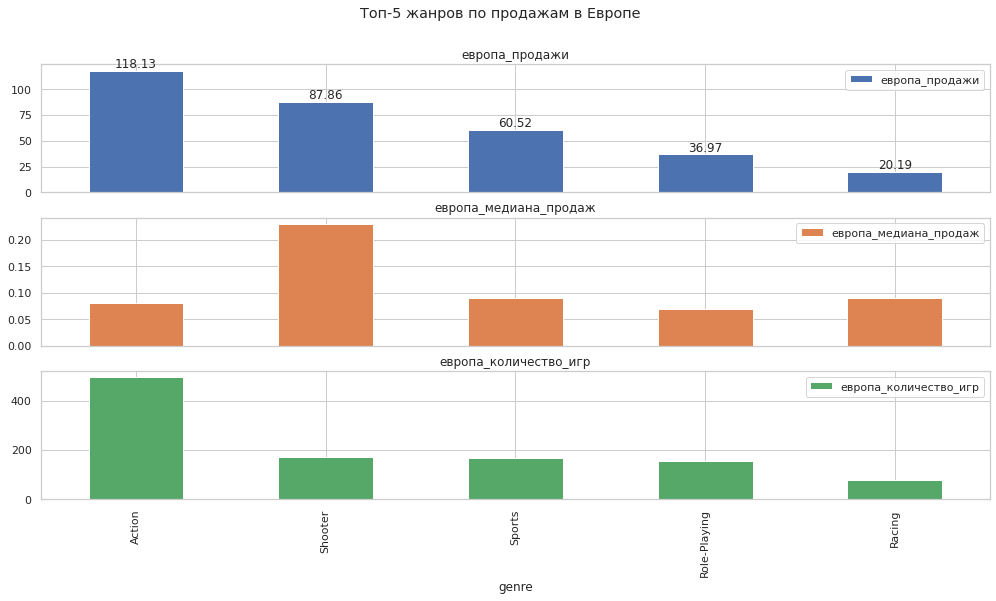

In [66]:
# выбор нужных столбцов и сортировка
eu_genre = ['genre', 'европа_продажи', 'европа_медиана_продаж', 'европа_количество_игр']
eu_sorted_genre = region_genre[eu_genre].sort_values(by='европа_продажи', ascending=False).head()

# построение графика
ax = eu_sorted_genre.plot(kind='bar', x='genre',
                          subplots=True, figsize=(17, 8),
                          title='Топ-5 жанров по продажам в Европе')

# добавление аннотаций с суммой продаж
for i, (genre, sales) in enumerate(zip(eu_sorted_genre['genre'], eu_sorted_genre['европа_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, eu_sorted_genre['европа_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

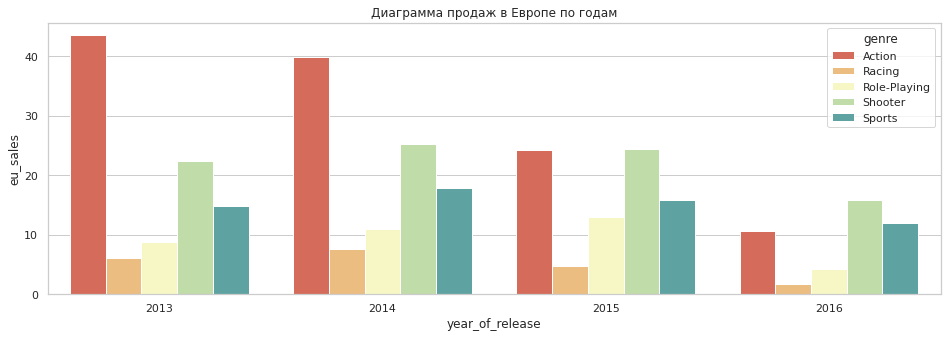

In [67]:
eu_year_genre = df_actuel.groupby(by=['year_of_release','genre']).agg({'eu_sales':'sum'}).reset_index()
eu_year_dinamic = eu_year_genre[eu_year_genre['genre'].isin(eu_sorted_genre['genre'])]

plt.figure(figsize=(16, 5))
sns.barplot(
    data=eu_year_dinamic,
    x='year_of_release',
    y='eu_sales',  
    hue= 'genre',
    palette='Spectral')
plt.title('Диаграмма продаж в Европе по годам')
plt.show()

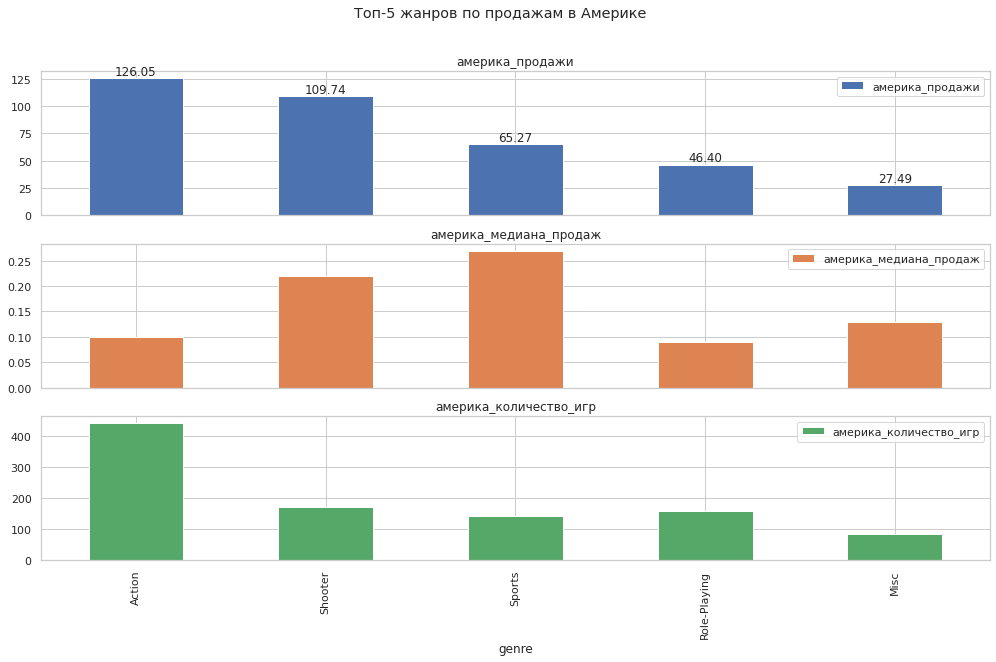

In [68]:
# выбор нужных столбцов и сортировка
na_genre = ['genre',  'америка_продажи', 'америка_медиана_продаж', 'америка_количество_игр']
na_sorted_genre = region_genre[na_genre ].sort_values(by='америка_продажи', ascending=False).head()

# построение графика
ax = na_sorted_genre.plot(kind='bar', x='genre',
                          subplots=True, figsize=(17, 9),
                          title='Топ-5 жанров по продажам в Америке')

# добавление аннотаций с суммой продаж
for i, (genre, sales) in enumerate(zip(na_sorted_genre['genre'], na_sorted_genre['америка_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, na_sorted_genre['америка_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

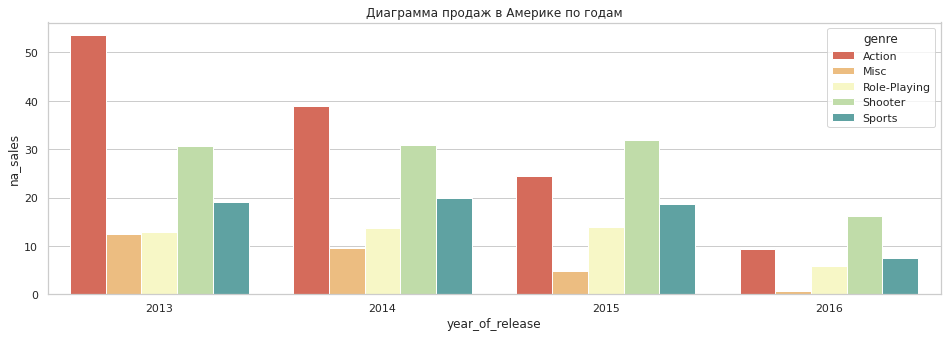

In [69]:
na_year_genre = df_actuel.groupby(by=['year_of_release','genre']).agg({'na_sales':'sum'}).reset_index()
na_year_dinamic = na_year_genre[na_year_genre['genre'].isin(na_sorted_genre['genre'])]

plt.figure(figsize=(16, 5))
sns.barplot(
    data=na_year_dinamic ,
    x='year_of_release',
    y='na_sales',  
    hue= 'genre',
    palette='Spectral')
plt.title('Диаграмма продаж в Америке по годам')
plt.show()

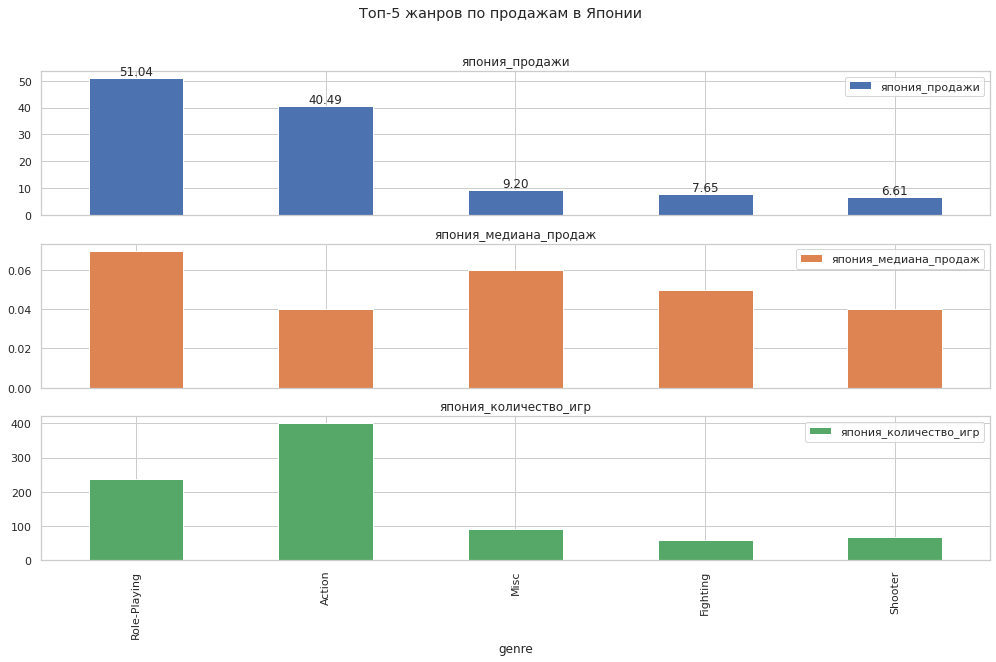

In [70]:
# Выбор нужных столбцов и сортировка
jp_genre = ['genre', 'япония_продажи', 'япония_медиана_продаж', 'япония_количество_игр']
jp_sorted_genre = region_genre[jp_genre ].sort_values(by='япония_продажи', ascending=False).head()

# Построение графика
ax = jp_sorted_genre.plot(kind='bar', x='genre',
                          subplots=True, figsize=(17, 9),
                          title='Топ-5 жанров по продажам в Японии')

# Добавление аннотаций с суммой продаж (тоже на первый график)
for i, (genre, sales) in enumerate(zip(jp_sorted_genre['genre'], jp_sorted_genre['япония_продажи'])):
    ax[0].annotate(f'{sales:.2f}', xy=(i, jp_sorted_genre['япония_продажи'].iloc[i]), 
                   ha='center', va='bottom')
plt.show()

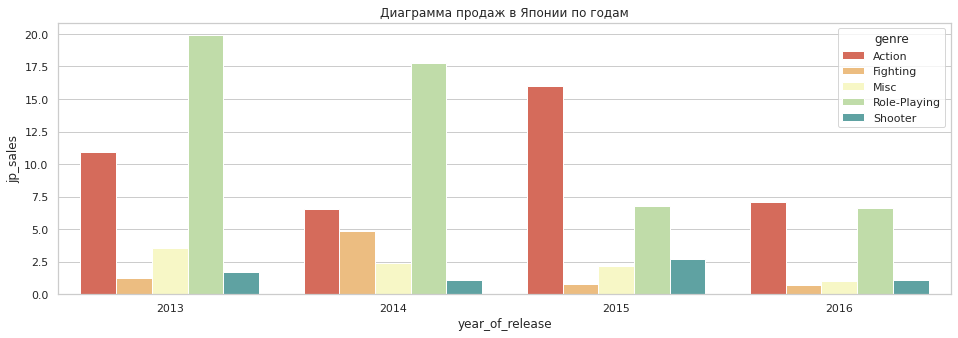

In [71]:
jp_year_genre = df_actuel.groupby(by=['year_of_release','genre']).agg({'jp_sales':'sum'}).reset_index()
jp_year_dinamic = jp_year_genre[jp_year_genre['genre'].isin(jp_sorted_genre['genre'])]

plt.figure(figsize=(16, 5))
sns.barplot(
    data=jp_year_dinamic,
    x='year_of_release',
    y='jp_sales',  
    hue= 'genre',
    palette='Spectral')
plt.title('Диаграмма продаж в Японии по годам')
plt.show()

**Самые популярные платформы в Европе - это Action, Shooter, Sports, Role-Playing, Racing с долями продаж от общих, по порядку, 30%, 22%, 15%, 9%, 5%. Растут продажи по годам по Shooter и Role-Playing, по остальным платформам падают.**

**Самые популярные платформы в Америке - Action, Shooter, Sports, Role-Playing, Misc с долями продаж от общих, по порядку, 30%, 22%, 15%, 9%, 5%. Падают продажи в динамике по годам Action и Misc, по остальным жанрам продажи в динамике без заничительных колебаний.**

**Самые популярные платформы в Японии - Role-Playing, Action, Misc, Fighting, Shooter с долями продаж от общих, по порядку, 36%, 29%, 7%, 5%, 5%. Падают Role-Playing, Misc и Fighting, растут жанры Action и Shooter.** 

**Возможные причины разностей долей платформ по регионам:**

**Культурные традиции:**

- В Японии любят нарративные игры с аниме-эстетикой, в США — динамичные экшены.

- Европа предпочитает социальные жанры (футбол, MMO).

**Платформы:**

- В Японии доминировали портативные консоли (3DS), в США/Европе — PS4/Xbox.

**Локализация:**

Западные RPG (The Witcher) почти не выходили в Японии, а японские визуальные новеллы редко локализировались для Запада.

### Определение, влияет ли рейтинг ESRB на продажи в отдельном регионе (NA, EU, JP):

In [72]:
# группировка данных по рейтингу ESRB и вычисление средних продаж
esrb_sales = (df_actuel
              .pivot_table(index='rating',
                                   values=['eu_sales','na_sales','jp_sales','sales_total'],
                                   aggfunc='mean')
              .sort_values(by='sales_total',ascending=False)
              .reset_index())
esrb_sales

,rating,eu_sales,jp_sales,na_sales,sales_total
0,M,0.393821,0.038238,0.447724,1.007263
1,E,0.276026,0.050132,0.261755,0.662781
2,E10+,0.169405,0.023373,0.215238,0.457897
3,T,0.125976,0.061832,0.149520,0.380240


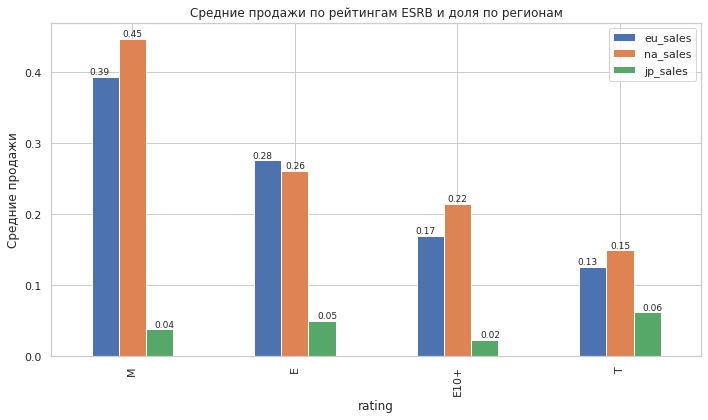

In [73]:
# визуализация средних продаж по регионам
ax = esrb_sales.plot(x='rating', y=['eu_sales', 'na_sales', 'jp_sales'], 
                    kind='bar', figsize=(10, 6), 
                    title='Средние продажи по рейтингам ESRB и доля по регионам')

# добавляем значения над каждым столбцом
for i, (_, row) in enumerate(esrb_sales.iterrows()):
    for j, col in enumerate(['eu_sales', 'na_sales', 'jp_sales']):
        height = row[col]
        ax.text(i + j*0.2  - 0.2, height, f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.ylabel('Средние продажи')
plt.tight_layout()
plt.show()

**Система ESRB включает рейтинги:**

- E («Everyone») — «Для всех». Содержание подходит для всех возрастов.
- E10+ («Everyone 10+») — «Для детей от 10 лет и старше». 
- T («Teen») — «Для подростков от 13 лет».
- M («Mature») — «Для взрослых от 17 лет». 

**Самые высокие продажи наблюдаются у категории M «Для взрослых от 17 лет».**

**Проверим гипотезу, что рейтинг ESRB влияет на продажи. Проведем тест и проверим есть ли статистически значимые различия средних значений между рейтингами при помощи теста Anova.**

**Гипотеза:**

- Н0: Средние продажи игр по рейтингам в каждой внутри каждого региона не различаются.

- Н1: Сущетсвует хотя бы 1 рейтинг, средние продажи которого отличаются от остальных внутри региона.

Установим уровень статистической значимости 5%.


In [74]:
# функция для проверки ANOVA
def anova_test(region):
    groups = [group[region].values for name, group in df_actuel.groupby('rating')]
    return st.f_oneway(*groups)

print("Северная Америка:", anova_test('na_sales'))
print("Европа:", anova_test('eu_sales')) 
print("Япония:", anova_test('jp_sales'))

Северная Америка: F_onewayResult(statistic=16.45943881087915, pvalue=1.7091312790258661e-10)
Европа: F_onewayResult(statistic=14.130430920548203, pvalue=4.631830017475628e-09)
Япония: F_onewayResult(statistic=4.040376159626078, pvalue=0.007155004585956066)


**Рейтинги в Америке:** 

p-value = 0.000000000171, крайне маленький 

Очень сильные статистически значимые различия в продажах между разными рейтингами ESRB.

По результатам теста, есть основания предполагать, что рейтинг ESRB существенно влияет на продажи в Северной Америке.
    
**Рейтинги в Европе:** 

p-value = 0.00000000463

Также очень значимые различия, но чуть менее выраженные, чем в Северной Америке.

Также есть основания предполагать, что ESRB влияет на европейские продажи, но слабее, чем в Америке.
    
**Рейтинги в Японии:** 

p-value = 0.007, также меньше 0.05

Различия статистически значимы, но значительно слабее, чем в других регионах

ESRB влияет на японский рынок, но это влияние менее выражено, чем в других регионах.


**Разница во влияния рейтингов ESRB заключается скорее всего  том, что ESRB - это Американская ситсема оценки. В Европа и Японии используются другие системы рейтингов: PEGI (Европа), CERO (Япония).**

## Проверка гипотез

### Гипотеза: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

**Сформируем гипотезу для проведения теста:**

**Н0:** Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

**Н1:** Средние пользовательские рейтинги платформ Xbox One и PC разные

**Для проверки гипотезы, проводем ttest для двух выборок, в качестве альтернативной используем двустороннюю гипотезу,так как арзница в средних рейтингах может быть в любую сторону.**

**Установим уровень статистической значимости 5%.**

In [75]:
# подготовка данных
xone_scores = df_actuel.query('platform=="XOne"')['user_score'].dropna()
pc_scores = df_actuel.query('platform=="PC"')['user_score'].dropna()

alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

# проводим ttest для двух выборок, в качестве альтернативной используем двустороннюю гипотезу 
results = st.ttest_ind(xone_scores,
                       pc_scores,
                       equal_var=True, alternative='two-sided')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем гипотезу')
else:
    print('Нет оснований отвергнуть гипотезу')

p-value: 0.14012658403611647
Нет оснований отвергнуть гипотезу


**По итогам проведения теста нулевую гипотезу не получилось отвергнуть. Значит, есть основания предполагать, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые.**

### Гипотеза:  Средние пользовательские рейтинги жанров Action и Sports разные

**Сформируем гипотезу для проведения теста:**

**Н0:** Средние пользовательские рейтинги жанров Action и Sports одинаковые

**Н1:** Средние пользовательские рейтинги жанров Action и Sports разные

**Для проверки гипотезы, также проводем ttest для двух выборок, используем двустороннюю гипотезу,так как разница в средних пользовательских рейтингах может быть в любую сторону.**

**Установим уровень статистической значимости 5%.**

In [76]:
# подготовка данных
action_scores = df_actuel.query('genre=="Action"')['user_score'].dropna()
sports_scores = df_actuel.query('genre=="Sports"')['user_score'].dropna()

alpha = 0.05 # уровень статистической значимости
# если p-value окажется больше него, отвергнем гипотезу

# проводим ttest для двух выборок, в качестве альтернативной используем двустороннюю гипотезу 
results = st.ttest_ind(action_scores,
                       sports_scores,
                       equal_var=True, alternative='two-sided')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue > alpha:
    print('Отвергаем альтернативную гипотезу')
else:
    print('Нет оснований отвергнуть альтернативную гипотезу')

p-value: 1.0517832389140023e-27
Нет оснований отвергнуть альтернативную гипотезу


**По итогам проведения теста альтернативную гипотезу не получилось отвергнуть. Значит, есть основания предполагать, что средние пользовательские рейтинги жанров Action и Sports разные.**

## ВЫВОД 

**Проведенные этапы работ:**

**Предобработка данных**

- Проведена стандартизация названий столбцов (нижний регистр).
- Удалены дубликаты (1 игра) и безымянные записи (2 строки).
- Исправлены типы данных: год релиза приведен к целочисленному формату, оценки пользователей — к числовому.
- Обработаны пропуски: заменены значения tbd на NaN, удалены 269 строк с отсутствующим годом релиза.
- Пропуски в рейтингах критиков, пользователей и ESRB признаны нормальными и сохранены.

**Исследовательский анализ данных:**

- Изучена динамика выпуска игр и их продаж с 1980 по 2016 год.
- Определены ключевые периоды роста и спада игровой индустрии.
- Проанализированы жизненные циклы игровых платформ.
- Выявлены наиболее прибыльные платформы, жанры и их зависимость от оценок критиков и пользователей.
- Построены портреты пользователей в разных регионах (Европа, Америка, Япония).
- Проверены гипотезы о влиянии рейтингов ESRB на продажи и сравнении пользовательских оценок платформ и жанров.

**Ключевые наблюдения и закономерности**

1. Динамика рынка

- Рост (1990–2009): Бурное развитие индустрии, увеличение числа релизов и продаж.
- Пик (2008–2009): Максимальные продажи при смене поколений консолей (7 платформ собрали рекордную выручку).
- Спад (после 2010): Сокращение продаж из-за перенасыщения рынка, роста стоимости разработки и конкуренции с мобильными играми.

**Платформы:**

- Лидеры продаж за все время: PS2, X360, PS3, Wii, DS, PS.
- Самые перспективные (2013–2016): PS4 и XOne — рост продаж и числа релизов.
- Жизненный цикл: В среднем 6–9 лет, после чего платформа теряет актуальность.

**Жанры:**

- Топ-4 по продажам (2013–2016): Action, Shooter, Sports, Role-Playing.
- Самые прибыльные на одну игру: Shooter (высокая медиана продаж при умеренном числе релизов).
- Аутсайдеры: Strategy и Puzzle — минимальные продажи и малое количество игр.

**Региональные различия:**

- Европа и Америка: Лидеры — PS4 и XOne; популярны Action, Shooter, Sports.
- Япония: Доминируют 3DS и PS4; предпочтение отдается Role-Playing и Action.
- Влияние рейтинга ESRB: Сильнее всего в Америке, слабее — в Японии (из-за локальных систем оценки).

**Факторы, влияющие на продажи:**

- Оценки пользователей: Нет значимой корреляции с продажами, кроме редких случаев (WiiU).
- Оценки критиков: Умеренная корреляция (0.4–0.42 для PS4 и XOne).
- Сравнение платформ: Пользовательские рейтинги Xbox One и PC статистически не различаются.

**Гипотезы:**

- Сравнение жанров: Оценки пользователей для Action и Sports значимо различаются.
- Сравнение платформ: Пользовательские рейтинги Xbox One и PC статистически не различаются

**Факторы успешности игры**

**1. На основе анализа можно выделить ключевые закономерности, определяющие коммерческий успех игры:**

- Платформа: Выпуск на актуальных платформах (PS4, XOne) увеличивает шансы на высокие продажи.
- Жанр: Наибольший потенциал у Shooter, Sports и Role-Playing, особенно в сочетании с высокими оценками критиков.

**2. Регион:**

- Для Европы и Америки важны рейтинги ESRB (M — "Для взрослых" лидирует).
- В Японии критичны жанровая направленность (ролевые игры) .
- Время выхода: Лучший период для максимизации продаж — первые 3–4 года после релиза платформы.

**3. Критики vs. игроки: Влияние оценок критиков значимо, а мнение пользователей почти не коррелирует с продажами.**

**Таким образом, для создания успешной игры в современных условиях стоит ориентироваться на актуальные платформы, популярные жанры и региональные предпочтения, а также уделять внимание оценкам профессиональных обозревателей.**